# 国・地域別アルコール消費の分布

run_id: `v020-exp-24`。Kaggleの公開データをAPIで検索し、国を等重みとする記述比較を行う。人の平均、因果効果、現在の消費量はこの分析の対象ではない。認証情報は一切記録しない。分析・取得はJupyter MCPだけで実行する。

In [1]:
from pathlib import Path
import sys, os, json, hashlib, io, contextlib, inspect
from datetime import datetime, timezone
from dataclasses import asdict
from contextlib import contextmanager
REPO = Path('/home/nahisaho/GitHub/jupytermind')
sys.path.insert(0, str(REPO / 'src'))
os.environ['AI_DATA_SCIENTIST_PROJECTS_ROOT'] = str(REPO / 'benchmark/projects')
from ai_data_scientist import project_manager, lifecycle, language_router
RUN_ID = 'v020-exp-24'
handle = project_manager.resolve_project('kaggle-v020-kaggle-exp-24-alcohol')
project_manager.ensure_notebook(handle)
data_dir = project_manager.ensure_data_dir(handle)
lifecycle.register_run(RUN_ID, handle.notebook_path)
phase_log = []
@contextmanager
def phase(name, writing=False):
    if lifecycle.is_cancel_requested(RUN_ID):
        raise RuntimeError('キャンセル要求を検知')
    start = lifecycle.mark_write_start if writing else lifecycle.mark_execution_start
    end = lifecycle.mark_write_end if writing else lifecycle.mark_execution_end
    start(RUN_ID)
    phase_log.append({'phase':name, 'event':'start', 'at':datetime.now(timezone.utc).isoformat()})
    try:
        yield
    except Exception:
        lifecycle.mark_failed(RUN_ID)
        phase_log.append({'phase':name, 'event':'failed', 'at':datetime.now(timezone.utc).isoformat()})
        raise
    finally:
        end(RUN_ID)
        phase_log.append({'phase':name, 'event':'end', 'at':datetime.now(timezone.utc).isoformat()})
def write_manifest(filename, value):
    with phase('記録:' + filename, writing=True):
        (data_dir / filename).write_text(json.dumps(value, ensure_ascii=False, indent=2, default=str), encoding='utf-8')
print('言語:', language_router.detect_language('国・地域別の消費量と分布を分析する'))
print('run_id:', RUN_ID)
print('初期状態:', asdict(lifecycle.get_run_status(RUN_ID)))

import nbformat, copy

def finalize_notebook_when_idle():
    status = lifecycle.get_run_status(RUN_ID)
    if status.active_cell_executions or status.pending_notebook_writes:
        raise RuntimeError('主Notebookが静止していないため書込みを停止')
    stage = nbformat.read(data_dir/'evidence-staging.ipynb',as_version=4)
    ready = [copy.deepcopy(c) for c in stage.cells if c.metadata.get('generated_summary')]
    assert len(ready)==4, '証拠付き解釈が4件そろっていない'
    def apply_results(nb):
        for new in ready:
            key = new.metadata.generated_summary
            old = next((c for c in nb.cells if c.metadata.get('generated_summary')==key),None)
            if old is None:
                raise RuntimeError('解釈の保存先セルがない')
            old.source = new.source
        image_count = 0
        for cell in nb.cells:
            chart_outputs = [o for o in cell.get('outputs',[]) if 'image/png' in o.get('data',{})]
            if not chart_outputs:
                continue
            specs = [o.get('metadata',{}).get('chart') for o in chart_outputs]
            assert all(specs), '画像ごとの監査メタデータが欠落'
            for spec in specs:
                assert not spec.get('missing_glyphs'), 'グリフ欠落あり'
                assert all(spec.get(k) for k in ['title','xlabel','ylabel','legend']), 'ラベルメタデータ欠落'
            cell.metadata.chart = {'title':' / '.join(s['title'] for s in specs),'xlabel':' / '.join(s['xlabel'] for s in specs),'ylabel':' / '.join(s['ylabel'] for s in specs),'legend':' / '.join(s['legend'] for s in specs),'missing_glyphs':[], 'charts':specs}
            # build_image_outputで生成した画像のMIMEをenqueue_writeでも永続化する。
            for output in chart_outputs:
                assert output['data']['image/png'], '画像MIMEが空'
            image_count += len(chart_outputs)
        assert image_count==5, '期待した5図がない'
        nb.metadata['analysis_run'] = {'run_id':RUN_ID,'finalized_at_utc':datetime.now(timezone.utc).isoformat(),'execution_route':'Jupyter MCP execute_cell','idle_write_strategy':'project_manager.enqueue_write','image_count':image_count}
    with phase('主Notebook静止時の証拠・画像反映',writing=True):
        project_manager.enqueue_write(handle,apply_results)
    print('静止時に解釈4件と画像5件の監査メタデータを反映しました。')


言語: ja
run_id: v020-exp-24
初期状態: {'run_id': 'v020-exp-24', 'state': 'running', 'active_cell_executions': 0, 'pending_notebook_writes': 0, 'locks_held': 0, 'notebook_path': '/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-24-alcohol/notebooks/kaggle-v020-kaggle-exp-24-alcohol.ipynb', 'reason': None}


## 取得来歴とKaggle検索

SDKの認証出力・例外本文は秘密情報保護のため抑制し、操作名と例外型だけを記録する。複数候補のファイル名・列を確認し、国別指標を持つCSVを選定する。Kaggle検索と取得に失敗した場合のみ指定フォールバックを使う。

In [2]:
import pandas as pd
from kaggle.api.kaggle_api_extended import KaggleApi
acquisition_log = []
search_rows = []
api_failure = None
selected_ref = None
selected_filename = None
metadata_text = ''
with phase('Kaggle公開データ検索・取得'):
    try:
        api = KaggleApi()
        # SDKの認証・通信出力を抑制。例外のメッセージやトークンは記録しない。
        with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
            api.authenticate()
        acquisition_log.append({'operation':'KaggleApi().authenticate()', 'status':'success'})
        for query in ['alcohol consumption by country', 'alcohol consumption']:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                found = api.dataset_list(search=query, page=1)
            rows = [{'ref':d.ref, 'title':d.title} for d in found]
            search_rows.extend(rows)
            acquisition_log.append({'operation':'dataset_list', 'search':query, 'results':rows})
        refs = list(dict.fromkeys(r['ref'] for r in search_rows))
        preferred = sorted(refs, key=lambda x:(not any(k in x.lower() for k in ['alcohol','drink']), x))
        options = []
        for ref in preferred[:12]:
            try:
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    listing = api.dataset_list_files(ref)
                names = [f.name for f in listing.files]
                acquisition_log.append({'operation':'dataset_list_files', 'ref':ref, 'files':names})
                for name in names:
                    if name.lower().endswith('.csv'):
                        options.append((ref,name))
            except Exception as exc:
                acquisition_log.append({'operation':'dataset_list_files', 'ref':ref, 'status':'failed', 'error_type':type(exc).__name__})
        options.sort(key=lambda v:(not any(k in v[1].lower() for k in ['drinks','alcohol','country']),v))
        for ref, name in options[:15]:
            try:
                dest = data_dir / ref.replace('/','--')
                dest.mkdir(exist_ok=True)
                with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                    api.dataset_download_file(ref, name, path=str(dest), force=True, quiet=True)
                path = dest / name
                if not path.exists():
                    import zipfile
                    archives = list(dest.glob('*.zip'))
                    if len(archives) != 1:
                        raise FileNotFoundError('ダウンロードファイルが見つからない')
                    with zipfile.ZipFile(archives[0]) as z:
                        csvnames = [n for n in z.namelist() if n.lower().endswith('.csv')]
                        target = next((n for n in csvnames if Path(n).name == Path(name).name), None)
                        if target is None:
                            raise FileNotFoundError('指定CSVがZIP内にない')
                        path = dest / Path(name).name
                        path.write_bytes(z.read(target))
                candidate = pd.read_csv(path)
                cols = {str(c).lower().strip():c for c in candidate.columns}
                acquisition_log.append({'operation':'dataset_download_file', 'ref':ref, 'filename':name, 'columns':list(candidate.columns), 'rows':len(candidate)})
                if 'country' in cols and ('total_litres_of_pure_alcohol' in cols or 'alcohol' in cols):
                    selected_ref, selected_filename, source_path = ref, name, path
                    raw = candidate
                    break
            except Exception as exc:
                acquisition_log.append({'operation':'dataset_download_file', 'ref':ref, 'filename':name, 'status':'failed', 'error_type':type(exc).__name__})
        if selected_ref is None:
            raise LookupError('検索候補から国別アルコールCSVを取得できなかった')
        # 内容定義を検証するため公開カタログの説明を保存。
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_metadata(selected_ref, path=str(source_path.parent))
            metadata_summary = json.loads((source_path.parent / 'dataset-metadata.json').read_text())
            metadata_summary['url'] = 'https://www.kaggle.com/datasets/' + selected_ref
        except Exception as exc:
            metadata_summary = {'error_type':type(exc).__name__, 'description':''}
    except Exception as exc:
        api_failure = {'error_type':type(exc).__name__, 'stage':acquisition_log[-1]['operation'] if acquisition_log else 'authenticate', 'reason':'Kaggle APIで対象CSVを検索・取得できないため指定の公開CSVへ移行。秘密情報を含みうる例外文字列は非表示。'}
        old_experiment = Path('/home/nahisaho/kaggle/experiments/white-paper.md')
        prior_text = old_experiment.read_text(encoding='utf-8')
        fallback_url = 'https://raw.githubusercontent.com/plotly/datasets/master/2010_alcohol_consumption_by_country.csv'
        if fallback_url not in prior_text:
            raise RuntimeError('指定旧実験資料にフォールバックURLがない')
        import urllib.request
        with urllib.request.urlopen(fallback_url, timeout=30) as response:
            payload = response.read(10_000_001)
        if len(payload) > 10_000_000:
            raise ValueError('CSVサイズ上限超過')
        source_path = data_dir / '2010_alcohol_consumption_by_country.csv'
        source_path.write_bytes(payload)
        raw = pd.read_csv(source_path)
        selected_filename = source_path.name
        metadata_summary = {'url':fallback_url, 'description':'公開CSV。Kaggle掲載版との完全な同一性は保証されない。'}
    provenance = {'run_id':RUN_ID, 'owner_dataset_slug':selected_ref, 'filename':selected_filename, 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'sha256':hashlib.sha256(source_path.read_bytes()).hexdigest(), 'source_url':metadata_summary.get('url'), 'api_failure':api_failure, 'file_bytes':source_path.stat().st_size}
    write_manifest('provenance.json', provenance)
    write_manifest('kaggle-search-log.json', acquisition_log)
    write_manifest('catalog-metadata.json', metadata_summary)
print('検索・取得ログ:', json.dumps(acquisition_log, ensure_ascii=False, indent=2))
print('取得来歴:', json.dumps(provenance, ensure_ascii=False, indent=2))
print('カタログ定義:', json.dumps(metadata_summary, ensure_ascii=False, indent=2))
print('サイズ:', raw.shape)
print(raw.head().to_string(index=False))
print('列:', raw.columns.tolist())


検索・取得ログ: [
  {
    "operation": "KaggleApi().authenticate()",
    "status": "success"
  },
  {
    "operation": "dataset_list",
    "search": "alcohol consumption by country",
    "results": [
      {
        "ref": "pralabhpoudel/alcohol-consumption-by-country",
        "title": "Alcohol Consumption by Country"
      },
      {
        "ref": "rishidamarla/alcohol-life-expectancy",
        "title": "Alcohol & Life Expectancy"
      },
      {
        "ref": "mattop/alcohol-consumption-per-capita-2016",
        "title": "Alcohol Consumption Per Capita 2016"
      },
      {
        "ref": "justmarkham/alcohol-consumption-by-country",
        "title": "Alcohol consumption by country"
      },
      {
        "ref": "saurabhbadole/life-expectancy-based-on-geographic-locations",
        "title": "Life Expectancy based on Geographic Locations"
      },
      {
        "ref": "iamsouravbanerjee/heart-attack-prediction-dataset",
        "title": "Heart Attack Risk Prediction Dataset"
      }

## データ辞書と地理カテゴリ

一次CSVには地域列がないため、UN M49に基づく公開地理対応表を別途取得する。同じ値を持つKaggle上のFiveThirtyEight版に付属するREADMEと照合し、測定年・単位の根拠を分離して記録する。同一由来の再掲載版は独立した測定検証とは扱わない。

In [3]:
from ai_data_scientist import ingestion, cleaning, eda, data_quality, data_definition, analysis_assumptions
import urllib.request
with phase('データ辞書・地域定義の取得'):
    provenance['source_url'] = 'https://www.kaggle.com/datasets/' + selected_ref if selected_ref else provenance['source_url']
    if selected_ref:
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                api.dataset_metadata(selected_ref, path=str(source_path.parent))
            catalog_path = source_path.parent / 'dataset-metadata.json'
            metadata_summary = json.loads(catalog_path.read_text())
        except Exception as exc:
            metadata_summary = {'error_type':type(exc).__name__, 'description':'カタログメタデータ取得失敗'}
    dictionary_ref = 'fivethirtyeight/fivethirtyeight-alcohol-consumption-dataset'
    dictionary_dir = data_dir / 'dictionary'
    dictionary_dir.mkdir(exist_ok=True)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        api.dataset_list_files(dictionary_ref)
        api.dataset_download_file(dictionary_ref, 'README.md', path=str(dictionary_dir), force=True, quiet=True)
        api.dataset_download_file(dictionary_ref, 'drinks.csv', path=str(dictionary_dir), force=True, quiet=True)
    # README/CSVが圧縮されたSDK版にも対応。
    import zipfile
    for name in ['README.md','drinks.csv']:
        p = dictionary_dir / name
        if not p.exists():
            archive = dictionary_dir / (name + '.zip')
            with zipfile.ZipFile(archive) as z:
                member = next(n for n in z.namelist() if Path(n).name == name)
                p.write_bytes(z.read(member))
    dictionary_text = (dictionary_dir / 'README.md').read_text()
    dictionary_df = pd.read_csv(dictionary_dir / 'drinks.csv')
    dictionary_equal = raw.equals(dictionary_df)
    dictionary_provenance = {'slug':dictionary_ref, 'csv_sha256':hashlib.sha256((dictionary_dir/'drinks.csv').read_bytes()).hexdigest(), 'readme_sha256':hashlib.sha256((dictionary_dir/'README.md').read_bytes()).hexdigest(), 'retrieved_at_utc':datetime.now(timezone.utc).isoformat(), 'exact_dataframe_equal':dictionary_equal}
    geo_url = 'https://raw.githubusercontent.com/datasets/country-codes/master/data/country-codes.csv'
    def fetch_geo(url):
        with urllib.request.urlopen(url, timeout=30) as response:
            b = response.read(5_000_001)
        if len(b) > 5_000_000:
            raise ValueError('地域対応データのサイズ上限超過')
        (data_dir / 'country-codes.csv').write_bytes(b)
        return pd.read_csv(io.BytesIO(b))
    geo_result = ingestion.ingest(ingestion.SourceSpec('api',geo_url), fetcher=fetch_geo, allowlist=('raw.githubusercontent.com',), row_limit=1000)
    geo = geo_result.dataframe
    geo_provenance = {'url':geo_url,'retrieved_at_utc':datetime.now(timezone.utc).isoformat(),'sha256':hashlib.sha256((data_dir/'country-codes.csv').read_bytes()).hexdigest(),'truncated':geo_result.truncated}
    write_manifest('provenance.json', provenance)
    write_manifest('dictionary-provenance.json', dictionary_provenance)
    write_manifest('geography-provenance.json', geo_provenance)
    write_manifest('catalog-metadata.json', metadata_summary)
print('カタログ:', json.dumps(metadata_summary,ensure_ascii=False,indent=2))
print('同一定義版照合:', json.dumps(dictionary_provenance,ensure_ascii=False,indent=2))
print('データ辞書原文:', dictionary_text)
print('地域表列:', geo.columns.tolist())
print(geo[['CLDR display name','UNTERM English Short','Region Name','Sub-region Name']].head().to_string(index=False))


カタログ: {
  "info": {
    "datasetId": 1084807,
    "datasetSlug": "alcohol-comsumption-around-the-world",
    "ownerUser": "codebreaker619",
    "usabilityRating": 1,
    "totalViews": 23471,
    "totalVotes": 62,
    "totalDownloads": 2781,
    "title": "Alcohol Comsumption around the World",
    "subtitle": "Alcohol Consumption by countries in Average serving sizes per person",
    "description": "### Content\n\nContains the data behind the story \"Dear Mona Followup: Where Do People Drink The Most Beer, Wine And Spirits?\"\n\nUnits: Average serving sizes per person Source: World Health Organisation, Global Information System on Alcohol and Health (GISAH), 2010",
    "keywords": [
      "alcohol",
      "health and fitness",
      "healthcare",
      "public health",
      "government",
      "food"
    ],
    "licenses": [
      {
        "name": "U.S. Government Works"
      }
    ],
    "expectedUpdateFrequency": "never",
    "userSpecifiedSources": "World Health Organisation, Glob

## 定義manifest・前提manifest・意味的異常検査

欠測、負値、非有限値、国名重複、地域カテゴリ、servingsの整数性を検査する。高値は直ちにエラーや除外とは扱わない。純アルコール列は列名によるリットル推定に留保し、年次・年齢分母・未記録消費・酒類別serving容量を未確認として明示する。地域は現代のUN M49対応であり、当時の境界を完全に再現しない。

In [4]:
import numpy as np
from IPython.display import display
from ai_data_scientist import sensitivity, visualization
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ft2font import FT2Font
import warnings, re
with phase('取込・意味的品質検査・地域対応'):
    load_result = ingestion.ingest(ingestion.SourceSpec('csv',str(source_path)),row_limit=1000)
    raw = load_result.dataframe
    cleaning_report = cleaning.clean_dataset(raw, operation='drop_duplicates')
    df = cleaning_report.dataframe.copy()
    metric = 'total_litres_of_pure_alcohol' if 'total_litres_of_pure_alcohol' in df else 'alcohol'
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    required = ['country',metric]
    assert set(required).issubset(df.columns), '必要な列がない'
    schema = {'country':{'not_null':True,'unique':True}, **{c:{'min':0,'not_null':True} for c in numeric_cols}}
    semantic_issues = data_quality.detect_anomalies(df,schema)
    extra_issues = {'empty_country_names':int(df.country.astype(str).str.strip().eq('').sum()), 'nonfinite_values':int((~np.isfinite(df[numeric_cols].to_numpy(dtype=float))).sum()),'fractional_servings':{c:int((df[c]%1!=0).sum()) for c in numeric_cols if c.endswith('_servings')}}
    assert not semantic_issues and not extra_issues['nonfinite_values'], '意味的異常を要確認'
    aliases = {'Bosnia-Herzegovina':'BIH',"Cote d'Ivoire":'CIV','Czech Republic':'CZE','DR Congo':'COD','St. Vincent & the Grenadines':'VCT','Sao Tome & Principe':'STP','Swaziland':'SWZ','Macedonia':'MKD','Turkey':'TUR','United Kingdom':'GBR','USA':'USA'}
    mapping_rows = []
    for country in df.country:
        if country in aliases:
            matches = geo.loc[geo['ISO3166-1-Alpha-3'].eq(aliases[country])]
            method = '明示的旧称・略称対応'
        else:
            match_mask = pd.Series(False,index=geo.index)
            for col in ['CLDR display name','UNTERM English Short','official_name_en']:
                match_mask |= geo[col].fillna('').str.casefold().eq(country.casefold())
            matches = geo.loc[match_mask]
            method = '地理表の国名と完全一致（大文字小文字除く）'
        if len(matches) != 1:
            raise ValueError(f'地域対応が一意でない: {country}, 件数={len(matches)}')
        row = matches.iloc[0]
        mapping_rows.append({'country':country, 'iso3':row['ISO3166-1-Alpha-3'],'region':row['Region Name'],'subregion':row['Sub-region Name'],'mapping_method':method})
    mapping = pd.DataFrame(mapping_rows)
    df = df.merge(mapping,on='country',how='left',validate='one_to_one')
    region_schema = {'region':{'not_null':True,'allowed':['Africa','Americas','Asia','Europe','Oceania']},'iso3':{'unique':True,'not_null':True}}
    region_issues = data_quality.detect_anomalies(df,region_schema)
    assert not region_issues, '地域カテゴリ異常あり'
    eda_report = eda.explore(df)
    coherence_flags = df.loc[(df[metric].eq(0) & df[[c for c in numeric_cols if c.endswith('_servings')]].sum(axis=1).gt(0)) | (df[metric].gt(0) & df[[c for c in numeric_cols if c.endswith('_servings')]].sum(axis=1).eq(0)), ['country']+numeric_cols]
    print('清掃影響:', {'rows_before':cleaning_report.rows_before,'rows_after':cleaning_report.rows_after,'rows_removed':cleaning_report.rows_removed,'columns_affected':cleaning_report.columns_affected})
    print('意味的異常:', [asdict(v) for v in semantic_issues], extra_issues)
    print('地域異常:',[asdict(v) for v in region_issues])
    print('丸め・飲料範囲の違いを要確認する不整合候補:', coherence_flags.to_dict('records'))
    print('欠損:',eda_report.missing_summary)
    print('カテゴリ:',json.dumps(eda_report.categorical_summary,ensure_ascii=False,default=str))
    print('国名別名対応:',mapping.loc[mapping.mapping_method.eq('明示的旧称・略称対応')].to_string(index=False))
    write_manifest('country-region-mapping.json',mapping.to_dict('records'))
    write_manifest('eda.json',asdict(eda_report))
    write_manifest('semantic-quality.json',{'schema':schema,'issues':[asdict(v) for v in semantic_issues], 'extra_checks':extra_issues, 'coherence_flags':coherence_flags.to_dict('records')})
with phase('データ定義・分析前提manifest'):
    F = data_definition.FieldValue
    definition_manifest = data_definition.build_manifest(
        source={'catalog':F(provenance['source_url'],'verified','Kaggle SDK'),'sha256':F(provenance['sha256'],'verified','取得ファイルのSHA-256'),'original_source':F('WHO GISAH','verified','カタログおよび同一CSV版README'),'original_method':F(None,'unknown','国別の推計・記録・未記録消費の区別は未提供')},
        dataset_scope={'year':F(2010,'verified','KaggleカタログとREADME'),'observation':F('1行1国、193か国','verified','CSV国名の一意性検査'),'denominator_age':F(None,'unknown','全人口か15歳以上かを記載資料から確認できない'),'period':F('年次','inferred','2010年の消費統計と列名から推定')},
        variables={'country':{'meaning':F('国名','verified','実データと地理表照合')},metric:{'unit':F('純アルコールのリットル','inferred','total_litres_of_pure_alcoholという列名'),'denominator':F('1人当たり','inferred','データセット全体説明からの適用。純アルコール列の個別辞書なし')},**{c:{'unit':F('平均servings/人','verified','カタログおよびREADME'),'serving_size_ml':F(None,'unknown','酒類ごとの1 servingのml・濃度定義なし')} for c in numeric_cols if c.endswith('_servings')},'region':{'classification':F('UN M49の5大地域。Americasは南北米・カリブをまとめる','verified',geo_provenance['url']),'historical_boundary':F('取得時点の地理表を2010年の国名へ対応','inferred','現代地理表。旧名称はISO3対応表で解決')}})
    unresolved = definition_manifest.unresolved_fields()
    inferred = [(f'{section}.{name}.{key}',asdict(value)) for section,groups in [('variables',definition_manifest.variables)] for name, fields in groups.items() for key,value in fields.items() if value.status=='inferred']
    inferred += [(f'dataset_scope.{k}',asdict(v)) for k,v in definition_manifest.dataset_scope.items() if isinstance(v,F) and v.status=='inferred']
    assumption_manifest = analysis_assumptions.AnalysisAssumptionManifest(
        analysis_scope={'target':'2010年CSVに収録された国の分布','aggregation':'国等重み。人口平均ではない'},causal_scope='descriptive',
        assumptions=(analysis_assumptions.Assumption('equal-country-weight','各国を等重みとし住民平均を推定しない','verified',impact_if_false='地域人口平均との混同',conclusion_critical=True),analysis_assumptions.Assumption('comparable-measurement','国間で分母・推計方法が比較可能である','assumed',impact_if_false='国順位・地域差を実際の住民消費差と解釈できない',conclusion_critical=True),analysis_assumptions.Assumption('zero-is-observed','ゼロはCSVの観測値として保持する。欠測と決めつけない','assumed',impact_if_false='下側分布と平均が変わる',conclusion_critical=True),analysis_assumptions.Assumption('geography-map','国名対応の一意性と5大地域カテゴリを検査した','tested',impact_if_false='地域集計の構成が変わる',conclusion_critical=True)))
    assumption_findings = analysis_assumptions.check_manifest(assumption_manifest)
    print('未解決定義:',[(k,asdict(v)) for k,v in unresolved])
    print('推定した定義:',inferred)
    print('前提検査の全指摘:',[asdict(v) for v in assumption_findings])
    write_manifest('data-definition-manifest.json',asdict(definition_manifest))
    write_manifest('analysis-assumptions-manifest.json',asdict(assumption_manifest))
with phase('初回記述集計'):
    country_summary = {'n':len(df),'mean':float(df[metric].mean()),'median':float(df[metric].median()),'q1':float(df[metric].quantile(.25)),'q3':float(df[metric].quantile(.75)),'min':float(df[metric].min()),'max':float(df[metric].max()),'zero_count':int(df[metric].eq(0).sum()),'zero_pct':float(df[metric].eq(0).mean()*100),'skew':float(df[metric].skew())}
    region_summary = df.groupby('region')[metric].agg(n='count',mean='mean',median='median',std='std',min='min',max='max')
    region_summary['q1'] = df.groupby('region')[metric].quantile(.25)
    region_summary['q3'] = df.groupby('region')[metric].quantile(.75)
    region_summary['zero_count'] = df[metric].eq(0).groupby(df.region).sum()
    region_summary = region_summary.sort_values('median',ascending=False)
    top_countries = df.sort_values([metric,'country'],ascending=[False,True])[['country','region',metric]].head(15)
    positive_bottom = df.loc[df[metric].gt(0)].sort_values([metric,'country'])[['country','region',metric]].head(10)
    print('地域比較（国等重み）:\n',region_summary.round(3).to_string())
    print('上位15か国:\n',top_countries.to_string(index=False))
    print('ゼロ以外の下位10か国:\n',positive_bottom.to_string(index=False))
    print('ゼロ記録国:',df.loc[df[metric].eq(0),'country'].tolist())
    evidence_initial = {'country_summary':country_summary,'region_summary':region_summary.reset_index().to_dict('records'),'top_countries':top_countries.to_dict('records'),'no_missing':int(df[numeric_cols].isna().sum().sum())}
    display({'text/plain':json.dumps(evidence_initial,ensure_ascii=False,indent=2)},raw=True)
    write_manifest('initial-results.json',evidence_initial)


清掃影響: {'rows_before': 193, 'rows_after': 193, 'rows_removed': 0, 'columns_affected': ['country', 'beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol']}
意味的異常: [] {'empty_country_names': 0, 'nonfinite_values': 0, 'fractional_servings': {'beer_servings': 0, 'spirit_servings': 0, 'wine_servings': 0}}
地域異常: []
丸め・飲料範囲の違いを要確認する不整合候補: []
欠損: {'country': {'missing_count': 0, 'missing_ratio': 0.0}, 'beer_servings': {'missing_count': 0, 'missing_ratio': 0.0}, 'spirit_servings': {'missing_count': 0, 'missing_ratio': 0.0}, 'wine_servings': {'missing_count': 0, 'missing_ratio': 0.0}, 'total_litres_of_pure_alcohol': {'missing_count': 0, 'missing_ratio': 0.0}, 'iso3': {'missing_count': 0, 'missing_ratio': 0.0}, 'region': {'missing_count': 0, 'missing_ratio': 0.0}, 'subregion': {'missing_count': 0, 'missing_ratio': 0.0}, 'mapping_method': {'missing_count': 0, 'missing_ratio': 0.0}}
カテゴリ: {"country": {"unique_count": 193, "top_values": [{"value": "Afghanistan", "count": 

{
  "country_summary": {
    "n": 193,
    "mean": 4.717098445595855,
    "median": 4.2,
    "q1": 1.3,
    "q3": 7.2,
    "min": 0.0,
    "max": 14.4,
    "zero_count": 13,
    "zero_pct": 6.7357512953367875,
    "skew": 0.42870418979394703
  },
  "region_summary": [
    {
      "region": "Europe",
      "n": 42,
      "mean": 9.061904761904762,
      "median": 10.2,
      "std": 3.1584924144553357,
      "min": 0.0,
      "max": 14.4,
      "q1": 6.825,
      "q3": 11.225000000000001,
      "zero_count": 2
    },
    {
      "region": "Americas",
      "n": 35,
      "mean": 6.102857142857142,
      "median": 6.3,
      "std": 2.1301043490437572,
      "min": 2.2,
      "max": 11.9,
      "q1": 4.300000000000001,
      "q3": 7.25,
      "zero_count": 0
    },
    {
      "region": "Africa",
      "n": 53,
      "mean": 3.0075471698113208,
      "median": 2.3,
      "std": 2.647556860477786,
      "min": 0.0,
      "max": 9.1,
      "q1": 0.7,
      "q3": 4.7,
      "zero_count": 3
  

## 初回図表

ヒストグラムと累積分布で全体の広がりを、全観測点付き箱ひげ図で地域内のばらつきを示す。上位棒グラフは0始点で国名を読める横向きにする。地図は国土面積による視覚的重みを避けるため使わない。人口重みがないので地域平均は住民平均ではない。箱ひげ図の点の横ずらしは固定乱数種24で見やすくする処理で、値を変更しない。

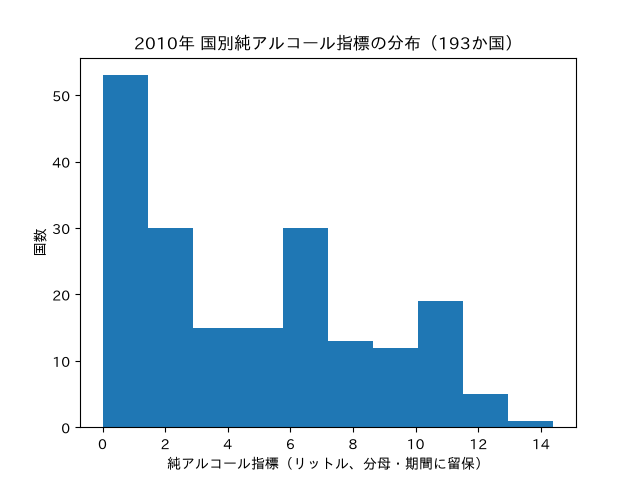

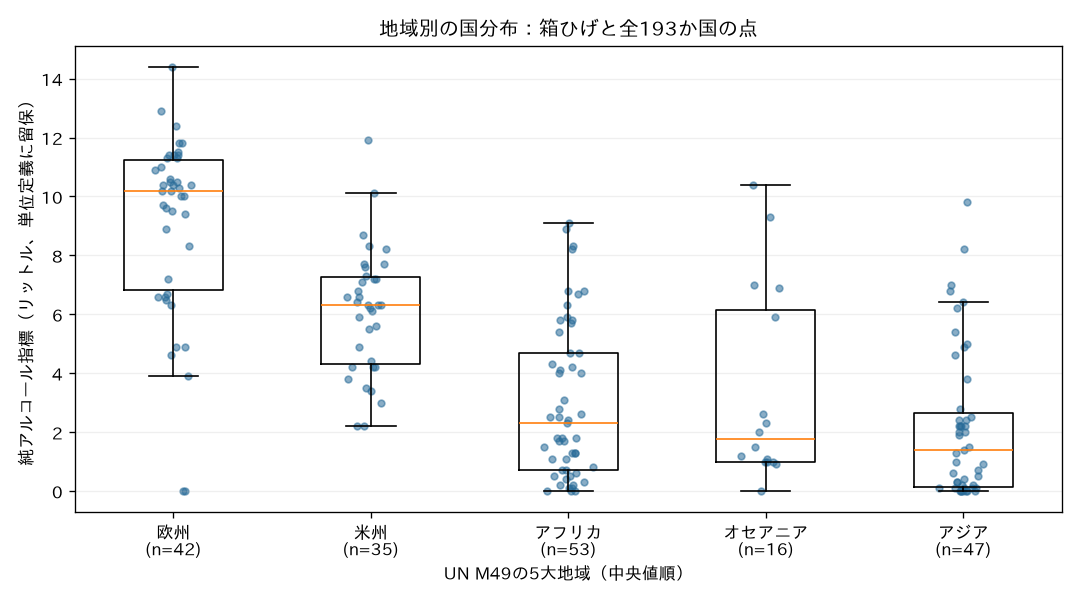

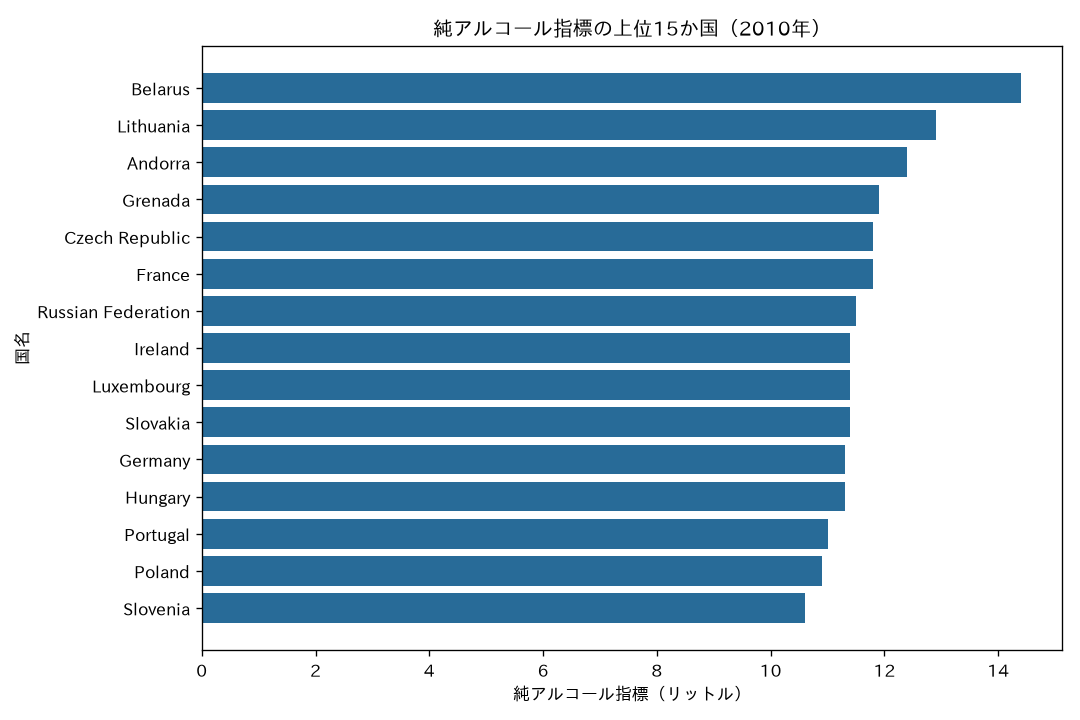

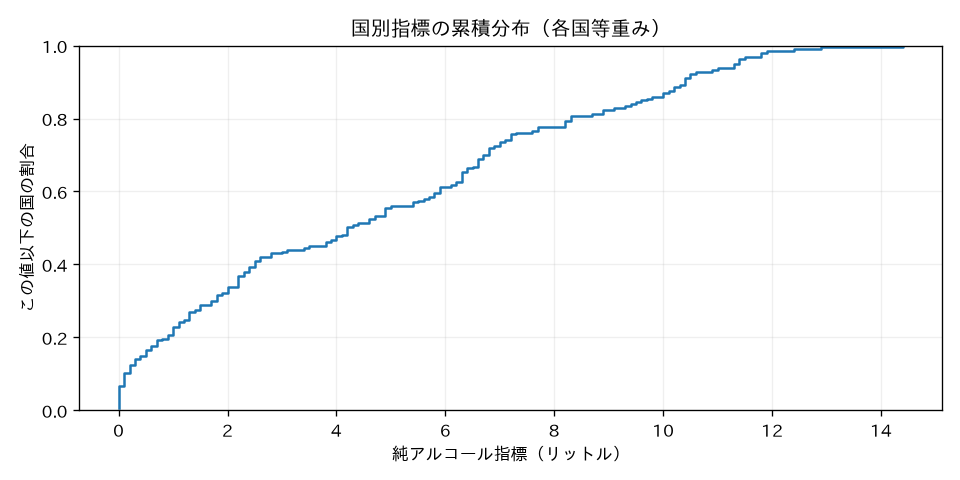

In [5]:
from ai_data_scientist import visualization
chart_specs = {}
def show_png(png, spec):
    bundle = visualization.build_image_output(png)
    display(bundle['data'], raw=True, metadata={'chart':spec})
def custom_chart(fig, ax, title, xlabel, ylabel, legend):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    fig.tight_layout()
    all_text = [t.get_text() for t in fig.findobj(match=__import__('matplotlib').text.Text) if t.get_visible()]
    missing = set()
    for t in fig.findobj(match=__import__('matplotlib').text.Text):
        cmap = FT2Font(fm.findfont(t.get_fontproperties())).get_charmap()
        missing.update(ord(c) for c in t.get_text() if not c.isspace() and ord(c) not in cmap)
    buf = io.BytesIO()
    fig.savefig(buf,format='png',dpi=120)
    plt.close(fig)
    spec = {'title':title,'xlabel':xlabel,'ylabel':ylabel,'legend':legend,'missing_glyphs':sorted(missing),'font_glyph_check':'描画テキストの実フォントcharmap検査'}
    assert not missing, '不足グリフを検知'
    show_png(buf.getvalue(),spec)
with phase('図表作成'):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter('always')
        png = visualization.render_chart(df,kind='hist',x=metric,title='2010年 国別純アルコール指標の分布（193か国）',xlabel='純アルコール指標（リットル、分母・期間に留保）',ylabel='国数')
    glyph_warnings = [str(w.message) for w in caught if 'Glyph' in str(w.message)]
    assert not glyph_warnings, '日本語グリフ警告あり'
    show_png(png,{'title':'国別指標のヒストグラム','xlabel':'純アルコール指標（リットル）','ylabel':'国数','legend':'単一系列のため凡例は不要','missing_glyphs':[],'glyph_warning_check':glyph_warnings})
    region_order = region_summary.index.tolist()
    region_labels = {'Europe':'欧州','Americas':'米州','Africa':'アフリカ','Oceania':'オセアニア','Asia':'アジア'}
    fig, ax = plt.subplots(figsize=(9,5))
    groups = [df.loc[df.region.eq(r),metric].to_numpy() for r in region_order]
    ax.boxplot(groups,tick_labels=[f'{region_labels[r]}\n(n={len(v)})' for r,v in zip(region_order,groups)],showfliers=False)
    rng = np.random.default_rng(24)
    for i,values in enumerate(groups,1):
        ax.scatter(rng.normal(i,.045,len(values)),values,s=16,alpha=.55,color='#286b98')
    ax.grid(axis='y',alpha=.2)
    custom_chart(fig,ax,'地域別の国分布：箱ひげと全193か国の点','UN M49の5大地域（中央値順）','純アルコール指標（リットル、単位定義に留保）','青点=各国、箱=四分位範囲、中央線=中央値、ひげ=1.5 IQR')
    fig, ax = plt.subplots(figsize=(9,6))
    chart_top = top_countries.iloc[::-1]
    ax.barh(chart_top.country,chart_top[metric],color='#286b98')
    ax.set_xlim(left=0)
    custom_chart(fig,ax,'純アルコール指標の上位15か国（2010年）','純アルコール指標（リットル）','国名','単一系列のため凡例は不要')
    fig, ax = plt.subplots(figsize=(8,4))
    sorted_values = np.sort(df[metric].to_numpy())
    ax.step(sorted_values,np.arange(1,len(df)+1)/len(df),where='post')
    ax.set_ylim(0,1)
    ax.grid(alpha=.2)
    custom_chart(fig,ax,'国別指標の累積分布（各国等重み）','純アルコール指標（リットル）','この値以下の国の割合','単一系列のため凡例は不要')


## 反復依頼履歴

### 反復1：原文

初回結果では欧州の中央値が高い一方、アフリカとオセアニアの順位が平均と中央値で逆転し、13か国にゼロ記録があります。ゼロを保持／除外、平均／中央値、上側5%のウィンズライジング有無、境界国を除外する地理区分の感度分析を行い、地域差の方向と大きさ、全地域順位がどこまで安定するか確認してください。ゼロを欠測と断定せず、各仕様の国数と残る限界を示してください。

**選定理由:** 初回集計セル7・図表セル9の読み直しで、ゼロの意味が未確認であり、地域の細かい順位が集約指標に依存すると判明した。境界国の所属も地域差に影響しうる。16仕様、相対変動許容20%を事前に設定する。上側クリップは疑わしい国を削除せず尾部の影響を試すために使う。

In [6]:
with phase('反復1:ゼロ・集約・尾部・地域区分の感度分析'):
    boundary_iso3 = ['RUS','TUR','KAZ','ARM','AZE','GEO','CYP']
    sensitivity_tables = []
    def prepare_spec(zero,tail,geography):
        subset = df.copy()
        if zero=='exclude':
            subset = subset.loc[subset[metric].gt(0)].copy()
        if geography=='omit_boundary':
            subset = subset.loc[~subset.iso3.isin(boundary_iso3)].copy()
        if tail=='winsor_upper_5pct':
            subset[metric] = subset[metric].clip(upper=subset[metric].quantile(.95))
        return subset
    def region_gap(statistic,zero,tail,geography):
        subset = prepare_spec(zero,tail,geography)
        summary = subset.groupby('region')[metric].agg(statistic)
        sensitivity_tables.append({'statistic':statistic,'zero':zero,'tail':tail,'geography':geography,'n':len(subset),'region_counts':subset.region.value_counts().to_dict(),'region_values':summary.to_dict(),'ranking':summary.sort_values(ascending=False).index.tolist(),'europe_minus_asia':float(summary['Europe']-summary['Asia'])})
        return float(summary['Europe']-summary['Asia'])
    sensitivity_plan = sensitivity.SensitivityPlan(parameter_grid={'statistic':['mean','median'],'zero':['keep','exclude'],'tail':['none','winsor_upper_5pct'],'geography':['UN_M49','omit_boundary']},max_runs=16)
    sensitivity_report = sensitivity.run_sensitivity(sensitivity_plan,region_gap,stability_tolerance=.20)
    all_europe_highest = all(row['ranking'][0]=='Europe' for row in sensitivity_tables)
    all_positive_gap = all(row['europe_minus_asia']>0 for row in sensitivity_tables)
    positive_summary = df.loc[df[metric].gt(0)].groupby('region')[metric].agg(n='count',mean='mean',median='median')
    full_zero_impact = {'keep_mean':float(df[metric].mean()),'exclude_mean':float(df.loc[df[metric].gt(0),metric].mean()),'keep_median':float(df[metric].median()),'exclude_median':float(df.loc[df[metric].gt(0),metric].median())}
    iteration1_result = {'sensitivity_report':asdict(sensitivity_report),'tolerance':.20,'europe_highest_in_all_specs':all_europe_highest,'europe_asia_gap_positive_in_all_specs':all_positive_gap,'gap_min':min(r['europe_minus_asia'] for r in sensitivity_tables),'gap_max':max(r['europe_minus_asia'] for r in sensitivity_tables),'regional_rankings':sorted(set(' > '.join(r['ranking']) for r in sensitivity_tables)),'zero_impact':full_zero_impact,'zero_excluded_region_summary':positive_summary.reset_index().to_dict('records')}
    print('全16仕様:',pd.DataFrame([{k:v for k,v in r.items() if k not in ['region_counts','region_values']} for r in sensitivity_tables]).to_string(index=False))
    print('ゼロ除外時:\n',positive_summary.to_string())
    display({'text/plain':json.dumps(iteration1_result,ensure_ascii=False,indent=2)},raw=True)
    write_manifest('sensitivity-specifications.json',sensitivity_tables)
    write_manifest('iteration-1-results.json',iteration1_result)
    print('解釈: stableは差の大きさが基準仕様から20%以内という判定。方向の安定性とは別。国数・分母を変更する仕様は頑健性の検査であり補正済み真値ではない。')


全16仕様: statistic    zero              tail     geography   n                                   ranking  europe_minus_asia
     mean    keep              none        UN_M49 193 [Europe, Americas, Oceania, Africa, Asia]           6.876798
     mean    keep              none omit_boundary 186 [Europe, Americas, Oceania, Africa, Asia]           7.153659
     mean    keep winsor_upper_5pct        UN_M49 193 [Europe, Americas, Oceania, Africa, Asia]           6.711560
     mean    keep winsor_upper_5pct omit_boundary 186 [Europe, Americas, Oceania, Africa, Asia]           6.980488
     mean exclude              none        UN_M49 180 [Europe, Americas, Oceania, Africa, Asia]           6.947500
     mean exclude              none omit_boundary 173 [Europe, Americas, Oceania, Africa, Asia]           7.234691
     mean exclude winsor_upper_5pct        UN_M49 180 [Europe, Americas, Oceania, Africa, Asia]           6.787500
     mean exclude winsor_upper_5pct omit_boundary 173 [Europe, Americas, 

{
  "sensitivity_report": {
    "results": [
      {
        "specification": {
          "statistic": "mean",
          "zero": "keep",
          "tail": "none",
          "geography": "UN_M49"
        },
        "value": 6.876798378926038
      },
      {
        "specification": {
          "statistic": "mean",
          "zero": "keep",
          "tail": "none",
          "geography": "omit_boundary"
        },
        "value": 7.153658536585367
      },
      {
        "specification": {
          "statistic": "mean",
          "zero": "keep",
          "tail": "winsor_upper_5pct",
          "geography": "UN_M49"
        },
        "value": 6.711560283687943
      },
      {
        "specification": {
          "statistic": "mean",
          "zero": "keep",
          "tail": "winsor_upper_5pct",
          "geography": "omit_boundary"
        },
        "value": 6.98048780487805
      },
      {
        "specification": {
          "statistic": "mean",
          "zero": "exclude",
 

### 反復2：原文

感度分析で欧州の集約値が最も高い方向は全16仕様で保たれましたが、純アルコール指標だけでは酒類カテゴリごとの違いは分かりません。ビール・蒸留酒・ワインの各servings列について地域別中央値・四分位範囲・ゼロ割合と国別上位を比較し、カテゴリごとに別パネルで図示してください。servingの容量と濃度が未確認なので、酒類間の合計・純アルコール比率・実際の嗜好を推定しないでください。

**選定理由:** 反復1セル11で純アルコール指標の地域差の方向は保たれたが、それを特定の酒類や飲料嗜好の違いに一般化できない。依頼のカテゴリ確認に対し未解決だった酒類別分布を確認する。証拠は次の集計・図表セル。

カテゴリ別の国分布:
        category   region  n  median     q1     q3  zero_pct
  beer_servings   Africa 53    32.0  15.00  76.00     5.660
  beer_servings Americas 35   159.0  97.50 198.00     0.000
  beer_servings     Asia 47    20.0   5.00  58.50    17.021
  beer_servings   Europe 42   227.0 143.75 276.75     4.762
  beer_servings  Oceania 16    52.5  21.00 125.75    12.500
spirit_servings   Africa 53     3.0   1.00  19.00    16.981
spirit_servings Americas 35   124.0  92.00 174.50     0.000
spirit_servings     Asia 47    21.0   1.00 100.50    21.277
spirit_servings   Europe 42   124.0  81.75 188.75     4.762
spirit_servings  Oceania 16    37.0  18.00  65.25    12.500
  wine_servings   Africa 53     2.0   1.00  13.00    18.868
  wine_servings Americas 35    11.0   4.00  40.50     0.000
  wine_servings     Asia 47     1.0   0.00   8.50    38.298
  wine_servings   Europe 42   128.5  64.75 207.75     4.762
  wine_servings  Oceania 16     8.5   1.00  23.25     6.250


{
  "beverage_summary": [
    {
      "category": "beer_servings",
      "region": "Africa",
      "n": 53,
      "median": 32.0,
      "q1": 15.0,
      "q3": 76.0,
      "zero_pct": 5.660377358490567
    },
    {
      "category": "beer_servings",
      "region": "Americas",
      "n": 35,
      "median": 159.0,
      "q1": 97.5,
      "q3": 198.0,
      "zero_pct": 0.0
    },
    {
      "category": "beer_servings",
      "region": "Asia",
      "n": 47,
      "median": 20.0,
      "q1": 5.0,
      "q3": 58.5,
      "zero_pct": 17.02127659574468
    },
    {
      "category": "beer_servings",
      "region": "Europe",
      "n": 42,
      "median": 227.0,
      "q1": 143.75,
      "q3": 276.75,
      "zero_pct": 4.761904761904762
    },
    {
      "category": "beer_servings",
      "region": "Oceania",
      "n": 16,
      "median": 52.5,
      "q1": 21.0,
      "q3": 125.75,
      "zero_pct": 12.5
    },
    {
      "category": "spirit_servings",
      "region": "Africa",
      "n

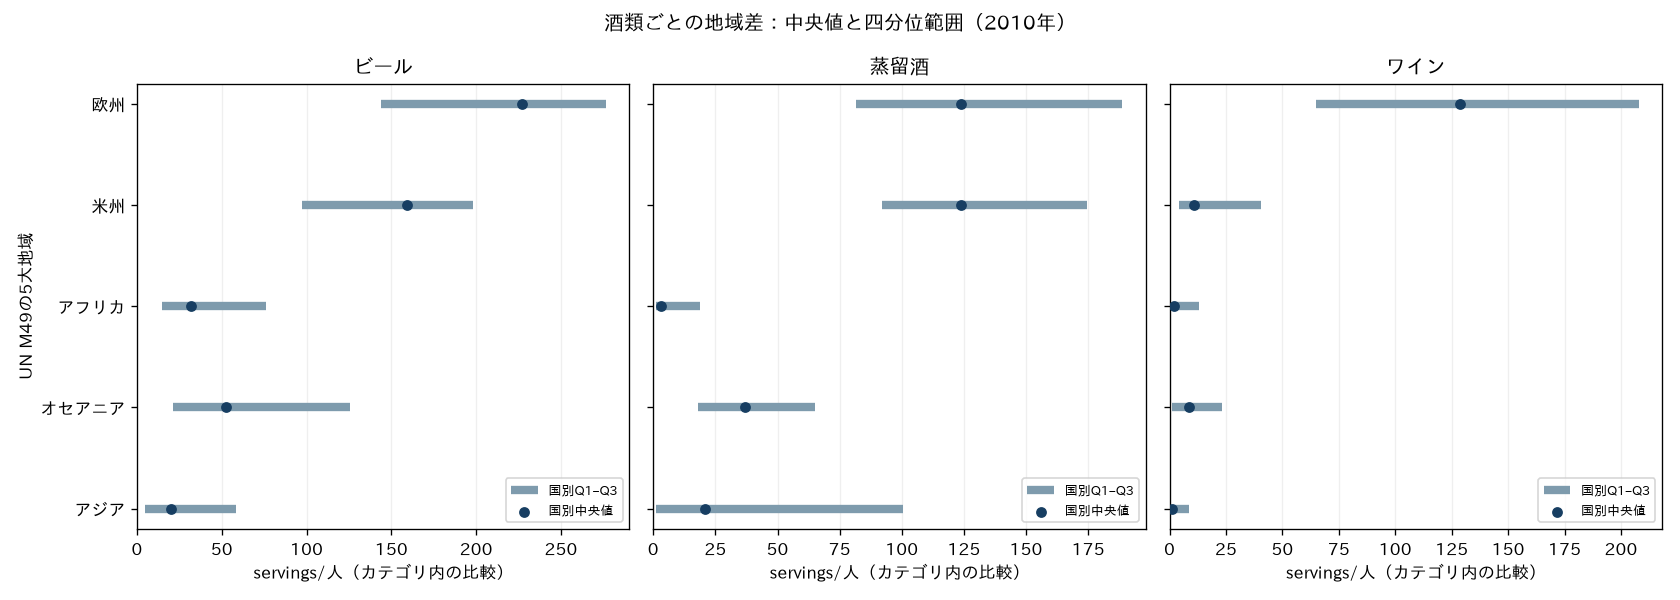

In [7]:
with phase('反復2:酒類カテゴリ別の分布'):
    beverage_cols = ['beer_servings','spirit_servings','wine_servings']
    beverage_names = {'beer_servings':'ビール','spirit_servings':'蒸留酒','wine_servings':'ワイン'}
    beverage_rows = []
    for col in beverage_cols:
        for region, group in df.groupby('region'):
            beverage_rows.append({'category':col,'region':region,'n':len(group),'median':float(group[col].median()),'q1':float(group[col].quantile(.25)),'q3':float(group[col].quantile(.75)),'zero_pct':float(group[col].eq(0).mean()*100)})
    beverage_table = pd.DataFrame(beverage_rows)
    beverage_top = {col:df.sort_values([col,'country'],ascending=[False,True])[['country','region',col]].head(5).to_dict('records') for col in beverage_cols}
    beverage_sensitivity = {}
    for col in beverage_cols:
        def beverage_gap(statistic,zero, column=col):
            subset = df if zero=='keep' else df.loc[df[column].gt(0)]
            med = subset.groupby('region')[column].agg(statistic)
            return float(med['Europe']-med['Asia'])
        report = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'statistic':['median','mean'],'zero':['keep','exclude']},max_runs=4),beverage_gap,stability_tolerance=.20)
        beverage_sensitivity[col] = asdict(report)
    print('カテゴリ別の国分布:\n',beverage_table.round(3).to_string(index=False))
    iteration2_result = {'beverage_summary':beverage_rows,'country_top5':beverage_top,'sensitivity':beverage_sensitivity,'unit_caveat':'servingsは酒類ごとに容量・度数不明。酒類間の量を直接比較・合算しない。'}
    display({'text/plain':json.dumps(iteration2_result,ensure_ascii=False,indent=2)},raw=True)
    write_manifest('iteration-2-results.json',iteration2_result)
with phase('反復2:カテゴリ別図表'):
    fig, axes = plt.subplots(1,3,figsize=(14,5),sharey=True)
    order = ['Europe','Americas','Africa','Oceania','Asia']
    for ax,col in zip(axes,beverage_cols):
        bt = beverage_table.loc[beverage_table.category.eq(col)].set_index('region').loc[order]
        y = np.arange(len(order))
        ax.hlines(y,bt.q1,bt.q3,color='#7e9bad',linewidth=5,label='国別Q1–Q3')
        ax.scatter(bt['median'],y,color='#173e62',s=30,zorder=3,label='国別中央値')
        ax.set_title(beverage_names[col])
        ax.set_xlabel('servings/人（カテゴリ内の比較）')
        ax.set_xlim(left=0)
        ax.set_yticks(y,labels=[region_labels[r] for r in order])
        ax.invert_yaxis() if ax is axes[0] else None
        ax.grid(axis='x',alpha=.2)
        ax.legend(fontsize=8,loc='lower right')
    fig.suptitle('酒類ごとの地域差：中央値と四分位範囲（2010年）')
    custom_chart(fig,axes[0],'ビール','servings/人（カテゴリ内の比較）','UN M49の5大地域','濃色点=国別中央値、横線=国別Q1–Q3')


### 反復3：原文

酒類別でも地域内の四分位範囲が広く、地域平均を各国の特徴へ一般化する危険が残ります。純アルコール指標をUN M49の小地域に分けて国数と中央値を確認し、欧州とアジア・米州の観測分布の重なりを全ての国の組合せ（同値は0.5）で定量化してください。オセアニアについて豪州・ニュージーランドを除いた場合も示し、大地域の順位が地域内の均質性や個人の飲酒行動を意味しないことを明確にしてください。小標本への有意差検定や因果推論は行わないでください。

**選定理由:** 反復2セル13の酒類別図表でも地域内分布が広い。反復1でオセアニアの細順位が変わったため、大地域内の構成と分布の重なりを検査する価値がある。国の組合せ割合はこの収録国集合の記述量であり、母集団確率や個人比較ではない。

In [8]:
with phase('反復3:地域内部の異質性と分布の重なり'):
    subregion_summary = df.groupby(['region','subregion'])[metric].agg(n='count',mean='mean',median='median',min='min',max='max')
    subregion_summary['q1'] = df.groupby(['region','subregion'])[metric].quantile(.25)
    subregion_summary['q3'] = df.groupby(['region','subregion'])[metric].quantile(.75)
    subregion_summary['small_n'] = subregion_summary['n'].lt(5)
    pairwise_superiority = {}
    eu = df.loc[df.region.eq('Europe'),metric].to_numpy()
    for other in ['Asia','Americas','Africa','Oceania']:
        other_values = df.loc[df.region.eq(other),metric].to_numpy()
        comparisons = eu[:,None]-other_values[None,:]
        pairwise_superiority[other] = {'pair_count':int(comparisons.size),'p_europe_greater_plus_half_ties':float(((comparisons>0).sum()+.5*(comparisons==0).sum())/comparisons.size),'p_europe_strictly_lower':float((comparisons<0).mean())}
    oceania = df.loc[df.region.eq('Oceania')]
    islands = oceania.loc[~oceania.iso3.isin(['AUS','NZL'])]
    oceania_split = {'all':{'n':len(oceania),'mean':float(oceania[metric].mean()),'median':float(oceania[metric].median())},'without_AUS_NZL':{'n':len(islands),'mean':float(islands[metric].mean()),'median':float(islands[metric].median())},'AUS_NZL':oceania.loc[oceania.iso3.isin(['AUS','NZL']),['country',metric]].to_dict('records')}
    def oceania_stat(statistic,exclude_AUS_NZL):
        target = islands if exclude_AUS_NZL else oceania
        return float(target[metric].agg(statistic))
    oceania_report = sensitivity.run_sensitivity(sensitivity.SensitivityPlan({'statistic':['mean','median'],'exclude_AUS_NZL':[False,True]},max_runs=4),oceania_stat,stability_tolerance=.20)
    total_ss = float(((df[metric]-df[metric].mean())**2).sum())
    between_ss = float(sum(len(g)*(g[metric].mean()-df[metric].mean())**2 for _,g in df.groupby('region')))
    descriptive_variance_decomposition = {'between_region_fraction':between_ss/total_ss,'within_region_fraction':1-between_ss/total_ss,'scope':'等重みの国指標の記述的分散分解。因果的説明率ではない。'}
    iteration3_result = {'subregions':subregion_summary.reset_index().to_dict('records'),'pairwise_superiority':pairwise_superiority,'oceania_split':oceania_split,'oceania_sensitivity':asdict(oceania_report),'variance_decomposition':descriptive_variance_decomposition}
    print('小地域比較（n<5はsmall_n）:\n',subregion_summary.round(3).to_string())
    display({'text/plain':json.dumps(iteration3_result,ensure_ascii=False,indent=2)},raw=True)
    write_manifest('iteration-3-results.json',iteration3_result)
    print('停止理由: 3回の追加分析でゼロ・集約・地理境界・酒類・地域内異質性を確認した。残る年齢分母、serving容量、国別推計方法、人口重みはこのCSVだけで解決できず、追加計算で確度は増さない。')


小地域比較（n<5はsmall_n）:
                                            n    mean  median  min   max      q1      q3  small_n
region   subregion                                                                              
Africa   Northern Africa                   6   0.733    0.60  0.0   1.7   0.275   1.150    False
         Sub-Saharan Africa               47   3.298    2.50  0.0   9.1   1.100   5.550    False
Americas Latin America and the Caribbean  33   5.961    6.30  2.2  11.9   4.200   7.200    False
         Northern America                  2   8.450    8.45  8.2   8.7   8.325   8.575     True
Asia     Central Asia                      5   2.820    2.40  0.3   6.8   2.200   2.400    False
         Eastern Asia                      5   5.340    5.00  0.0   9.8   4.900   7.000    False
         South-eastern Asia               11   2.191    1.50  0.1   6.4   0.200   3.400    False
         Southern Asia                     9   0.556    0.00  0.0   2.2   0.000   0.400    False
         

{
  "subregions": [
    {
      "region": "Africa",
      "subregion": "Northern Africa",
      "n": 6,
      "mean": 0.7333333333333334,
      "median": 0.6,
      "min": 0.0,
      "max": 1.7,
      "q1": 0.275,
      "q3": 1.15,
      "small_n": false
    },
    {
      "region": "Africa",
      "subregion": "Sub-Saharan Africa",
      "n": 47,
      "mean": 3.297872340425532,
      "median": 2.5,
      "min": 0.0,
      "max": 9.1,
      "q1": 1.1,
      "q3": 5.550000000000001,
      "small_n": false
    },
    {
      "region": "Americas",
      "subregion": "Latin America and the Caribbean",
      "n": 33,
      "mean": 5.96060606060606,
      "median": 6.3,
      "min": 2.2,
      "max": 11.9,
      "q1": 4.2,
      "q3": 7.2,
      "small_n": false
    },
    {
      "region": "Americas",
      "subregion": "Northern America",
      "n": 2,
      "mean": 8.45,
      "median": 8.45,
      "min": 8.2,
      "max": 8.7,
      "q1": 8.325,
      "q3": 8.575,
      "small_n": true


## 使用したJupytermindモジュール

以下はこのNotebookのコードセル内で直接import・呼び出したものだけを列挙する。関数内部の間接importを使用済みとは数えない。

| モジュール | 直接使用した関数・クラス | 使用目的 |
|---|---|---|
| `ai_data_scientist.project_manager` | `ProjectHandle`, `resolve_project`, `ensure_notebook`, `ensure_data_dir`, `enqueue_write` | 保存先検証、データ領域、セル・証拠・監査メタデータの直列書込み |
| `ai_data_scientist.language_router` | `detect_language` | 日本語判定 |
| `ai_data_scientist.lifecycle` | `register_run`, `mark_execution_start/end`, `mark_write_start/end`, `is_cancel_requested`, `mark_completed`, `mark_failed`, `get_run_status`, `wait_for_quiescence` | 取得前登録、実行・書込み・失敗・終了と静止確認 |
| `ai_data_scientist.ingestion` | `SourceSpec`, `ingest` | CSV取込、地域表のホスト許可と行上限 |
| `ai_data_scientist.cleaning` | `clean_dataset` | 完全重複行検査・影響記録 |
| `ai_data_scientist.eda` | `explore` | 型、欠測、統計量、カテゴリ頻度 |
| `ai_data_scientist.data_quality` | `detect_anomalies` | 非負・欠測・一意性・地域カテゴリの意味的検査 |
| `ai_data_scientist.data_definition` | `FieldValue`, `build_manifest`, `DataDefinitionManifest.unresolved_fields` | 定義の検証済み／推定／不明の区別 |
| `ai_data_scientist.analysis_assumptions` | `Assumption`, `AnalysisAssumptionManifest`, `check_manifest` | 分母比較可能性・ゼロ等の前提の全指摘記録 |
| `ai_data_scientist.sensitivity` | `SensitivityPlan`, `run_sensitivity` | 16仕様と酒類・地域内の4仕様の変動判定 |
| `ai_data_scientist.visualization` | `render_chart`, `build_image_output` | 日本語ヒストグラムとPNG MIME生成 |
| `ai_data_scientist.insight_engine` | `extract_cited_value`, `record_insight` | 実行済み出力からの引用、証拠付き解釈 |
| `ai_data_scientist.notebook_audit` | `audit_notebook`, `audit_visual_outputs` | 全セル・証拠・画像監査、欠落メタデータの最小再現 |

`mcp_gateway.run_and_record`は未使用：この実行環境はツール呼出しを外部オーケストレータが管理し、Notebookカーネルにgateway用MCPClientを渡していない。代わりに実際のJupyter MCP `execute_cell`のみでコードを実行し、セルの手動作成・更新は`enqueue_write`、実行結果の保存はMCPに担当させた。偽MCPClientやローカルexecによる代替はしていない。

## 適用しない機能と理由

独立した同年・同定義の消費測定データは取得していないため、`data_quality.validate_anomalies`と`dataset_validation.compare_datasets`による独立検証は実施しない。照合したFiveThirtyEight版は同じSHA-256の再掲載であり、測定の正しさを独立に裏付けない。地域表は地理分類だけを提供する。z-scoreで高値を誤値扱いしないため統計的異常除去は行わない。国が独立無作為標本だと仮定できず、依頼も記述比較なので有意差検定・相関・因果推定は行わない。人口・正確な分母・serving容量がないため人口重み集計・純アルコール換算をしない。時系列・予測・MLは単年の国比較の目的に適合しない。

## Jupytermind改善候補

**分類:** 画像監査の機能不足候補。**再現条件:** 実際の画像セルのコピーから`cell.metadata.chart`だけを削除し、`notebook_audit.audit_visual_outputs`を呼ぶ。**期待:** タイトル・軸・凡例・グリフの監査根拠が欠落していると検出する。**実際:** 欠落自体に対する指摘が返らない（直後のセル出力と`data/improvement-reproduction.json`を参照）。**影響:** 画像作成側がメタデータを付け忘れた場合に監査の見逃しがありうる。**回避策:** 画像ごとの実際のラベル・グリフ検査を出力メタデータへ付け、最後にセルへ集約して存在をassertし、実図も目視確認する。**関係するセル:** 初回図表セル9、酒類図表セル13、次の最小再現・証拠記録セル、末尾監査セル。**ログ:** `improvement-reproduction.json`と`notebook-audit.json`。

Kaggle SDKに`dataset_view`が存在しなかった初期試行はKaggle API固有のメソッド差異であり、Jupytermindの候補には含めない。公開メタデータは対応する`dataset_metadata`で取得した。Jupyter MCPが保存先の未作成親ディレクトリを拒否した件もJupytermind不具合ではなく、`ensure_notebook`で解決した。Copilot CLI・ベンチマークランナー固有の不具合として推測・混同しない。


**追加候補（連携・責任境界は未確定）:** 実行中のNotebook自身へ`enqueue_write`／`record_insight`でセルを追加した初回証拠記録で、追加した4つの解釈セルは保存された一方、実行中セル17の出力とexecution_countが保存されなかった。期待は同時書込み後もMCPの実行結果が保持されること。影響は監査で未実行扱いになること。回避策は同一Notebookの実行中に物理書込みを行わず、証拠用ステージNotebookへ記録し、主Notebookが静止した後にJupyter MCPの別セルから`enqueue_write`で反映すること。関係セル17、監査セル、ログ`write-integration-observation.json`。これはJupytermindとJupyter MCPの書込み同期の改善候補であり、Jupytermind単独の原因とは断定しない。Copilot CLI・Kaggle認証・ベンチマークランナーの問題とは分離する。

**再現手順:** Jupyter MCPでカーネルを再起動し、主Notebookの全コードセルを上から実行する。末尾監査の直前に、静止中の主Notebookへステージ内の`generated_summary`セルを同キーで置換し、画像の出力`metadata.chart`をセルの`metadata.chart`にも反映する。この静止時反映のコードは末尾監査セルの`finalize_notebook_when_idle`として記録してある。監査セル内では主Notebookを書き換えない。


In [9]:
import nbformat, copy
from ai_data_scientist import insight_engine, notebook_audit
with phase('改善候補の最小再現・実行証拠確認'):
    saved_nb = nbformat.read(handle.notebook_path,as_version=4)
    saved_charts = [c for c in saved_nb.cells if any('image/png' in o.get('data',{}) for o in c.get('outputs',[]))]
    repro_chart = copy.deepcopy(saved_charts[0])
    repro_chart.metadata.pop('chart',None)
    repro_nb = nbformat.v4.new_notebook(cells=[repro_chart])
    repro_findings = notebook_audit.audit_visual_outputs(repro_nb,(0,))
    improvement_log = {'classification':'Jupytermind監査機能不足の候補','module':'ai_data_scientist.notebook_audit.audit_visual_outputs','reproduction':'実際に描画した画像セルのcell.metadata.chartを削除したコピーを監査する。画像の出力自体は変更しない。','expected':'chartメタデータが存在しないことを検出する','actual':[asdict(v) for v in repro_findings],'impact':'作成側がメタデータを付け忘れると、ラベル・グリフの監査が行われなくても図が合格扱いになる可能性','workaround':'各画像の実測chartメタデータを出力に付与し、最終監査前にセルにも複製して存在をassertする。実図の目視も実施。','related_cells':[9,13],'related_log':'improvement-reproduction.json','separation':'Kaggle API認証・SDKメソッド差異、Copilot CLI、ベンチマークランナーではなく、Jupytermind関数への直接入力で再現した。'}
    print('改善候補の再現:',json.dumps(improvement_log,ensure_ascii=False,indent=2))
    write_manifest('improvement-reproduction.json',improvement_log)
    def evidence_for(marker):
        cell = next(c for c in saved_nb.cells if c.cell_type=='code' and marker in c.source)
        outputs = [o.get('data',{}).get('text/plain','') for o in cell.get('outputs',[])]
        text = next(str(v) for v in outputs if str(v).lstrip().startswith('{'))
        cited = insight_engine.extract_cited_value({'output':text},r'(?s)(\{.*\})')
        return cell.execution_count,cited
    table_lines = ['| 地域 | 国数 | 平均 | 中央値 | Q1–Q3 |','|---|---:|---:|---:|---:|']
    for r,row in region_summary.iterrows():
        table_lines.append(f'| {region_labels[r]} | {int(row.n)} | {row["mean"]:.2f} | {row["median"]:.2f} | {row.q1:.2f}–{row.q3:.2f} |')
    initial_text = ('**初回結果と解釈（証拠：初回記述集計セル）**\n\n'
        + f'193か国の純アルコール指標は平均{country_summary["mean"]:.2f}、中央値{country_summary["median"]:.2f}、四分位範囲{country_summary["q1"]:.2f}–{country_summary["q3"]:.2f}、範囲0–{country_summary["max"]:.1f}。平均が中央値より高く、低値付近に多い広い分布である。ゼロ記録は{country_summary["zero_count"]}か国（{country_summary["zero_pct"]:.2f}%）。最大はBelarus、次いでLithuaniaとAndorra。\n\n'
        + '\n'.join(table_lines)
        + '\n\n数値はCSVの純アルコール指標。リットルは列名による推定で、年齢分母・期間・未記録消費の扱いは未確認。国等重みの平均を世界や地域住民の1人当たり平均として読まない。地域内の分布を図表でも確認する。')
    iteration1_text = ('**反復1の結果・証拠・残る限界**\n\n'
        + f'全16仕様で欧州の地域集約値が最大であり、欧州−アジア差は正。ただし差は{iteration1_result["gap_min"]:.2f}–{iteration1_result["gap_max"]:.2f}、最大相対変動{100*sensitivity_report.max_relative_deviation:.1f}%、`stable={sensitivity_report.stable}`（許容20%）。したがって「高い方向」はこの仕様集合で保たれるが、大きさまで安定とはいえない。平均はアフリカよりオセアニアが高く、中央値は逆で、下位3地域の順位は仕様に依存する。\n\n'
        + f'ゼロを除外すると全体平均は{full_zero_impact["exclude_mean"]:.2f}、中央値は{full_zero_impact["exclude_median"]:.2f}となる。これは13か国を除く条件付きの比較で、ゼロが欠測だと確認した補正ではない。証拠は反復1の16仕様出力と`sensitivity-specifications.json`。測定方法の国間互換性やゼロの意味は依然未確認。')
    iteration2_text = ('**反復2の結果・証拠・残る限界**\n\n'
        + '国別servingsの地域中央値は、欧州のビール227・ワイン128.5が他の大地域より高い。蒸留酒は欧州・米州とも124で、総指標の順位を全酒類へ一般化できない。国別最大はビールNamibia 376、蒸留酒Grenada 438、ワインFrance 370で、総指標最大のBelarusとは異なる。\n\n'
        + f'平均／中央値、カテゴリのゼロ保持／除外の4仕様で、欧州−アジア差の感度判定はビールstable={beverage_sensitivity["beer_servings"]["stable"]}（最大相対変動{100*beverage_sensitivity["beer_servings"]["max_relative_deviation"]:.1f}%）、蒸留酒stable={beverage_sensitivity["spirit_servings"]["stable"]}（{100*beverage_sensitivity["spirit_servings"]["max_relative_deviation"]:.1f}%）、ワインstable={beverage_sensitivity["wine_servings"]["stable"]}（{100*beverage_sensitivity["wine_servings"]["max_relative_deviation"]:.1f}%）。証拠はカテゴリ別中央値・Q1–Q3・ゼロ率・上位5か国と3パネル図。serving容量と度数が不明なので酒類間の合算、純アルコール構成比、嗜好や個人の飲酒を推測しない。')
    iteration3_text = ('**反復3の結果・証拠・残る限界**\n\n'
        + f'全ての収録国の組合せで欧州側が高い割合（同値を半分加算）は、アジアとの比較で{100*pairwise_superiority["Asia"]["p_europe_greater_plus_half_ties"]:.1f}%、米州との比較で{100*pairwise_superiority["Americas"]["p_europe_greater_plus_half_ties"]:.1f}%。欧州が全ての他地域国より高いわけではない。国指標の全分散のうち地域内分散が{100*descriptive_variance_decomposition["within_region_fraction"]:.1f}%あり、大地域の差だけでは国差の全体を表せない。因果的な説明率ではない。\n\n'
        + f'オセアニアは16か国の平均{oceania_split["all"]["mean"]:.2f}に対し、豪州・NZを除く14か国は{oceania_split["without_AUS_NZL"]["mean"]:.2f}（中央値{oceania_split["without_AUS_NZL"]["median"]:.2f}）。集約方法と除外条件の4仕様はstable={oceania_report.stable}、最大相対変動{100*oceania_report.max_relative_deviation:.1f}%。小地域表では東アジアの中央値5.0と南アジア0.0など内部差がある。証拠は反復3の17小地域表、組合せ件数、オセアニア内訳、記述的分散分解。n<5の小地域は一般化を避ける。\n\n3回で停止する。残る分母年齢・serving容量・推計方法・人口重み・現在への外挿は、このデータの追加計算では解決できない。現在や個人に関する推測、有意差による過剰な確信、宗教・政策・文化による因果説明は行わない。')
    claims = [('initial','country_summary =',initial_text),('iteration1','boundary_iso3 =',iteration1_text),('iteration2','beverage_cols =',iteration2_text),('iteration3','subregion_summary =',iteration3_text)]
    stage_handle = project_manager.ProjectHandle(name=handle.name,root=handle.root,notebook_path=data_dir/'evidence-staging.ipynb',data_dir=data_dir)
    project_manager.ensure_notebook(stage_handle)
    evidence_cells = [copy.deepcopy(next(c for c in saved_nb.cells if c.cell_type=='code' and marker in c.source)) for _,marker,_ in claims]
    with phase('証拠用ステージ準備',writing=True):
        project_manager.enqueue_write(stage_handle,lambda nb: setattr(nb,'cells',evidence_cells))
    for key,marker,text in claims:
        count,cited = evidence_for(marker)
        manifest = {'execution_count':count,'cited_value':cited,'claim_type':'descriptive'}
        source = text+'\n\n```evidence\n'+json.dumps(manifest,ensure_ascii=False)+'\n```'
        with phase('証拠付き解釈のステージ記録:'+key,writing=True):
            insight_engine.record_insight(stage_handle,text,count,cited,'descriptive',language='ja')
            project_manager.enqueue_write(stage_handle,lambda nb,key=key:nb.cells[-1].metadata.update({'generated_summary':key}))
    stage_nb = nbformat.read(stage_handle.notebook_path,as_version=4)
    pending_insight_cells = [copy.deepcopy(c) for c in stage_nb.cells if c.metadata.get('generated_summary')]
    for c in pending_insight_cells:
        display({'text/markdown':c.source,'text/plain':c.source},raw=True)
    print('実行済み出力から抽出した証拠で、初回および反復1–3の日本語解釈を記録しました。')


改善候補の再現: {
  "classification": "Jupytermind監査機能不足の候補",
  "module": "ai_data_scientist.notebook_audit.audit_visual_outputs",
  "reproduction": "実際に描画した画像セルのcell.metadata.chartを削除したコピーを監査する。画像の出力自体は変更しない。",
  "expected": "chartメタデータが存在しないことを検出する",
  "actual": [],
  "impact": "作成側がメタデータを付け忘れると、ラベル・グリフの監査が行われなくても図が合格扱いになる可能性",
  "workaround": "各画像の実測chartメタデータを出力に付与し、最終監査前にセルにも複製して存在をassertする。実図の目視も実施。",
  "related_cells": [
    9,
    13
  ],
  "related_log": "improvement-reproduction.json",
  "separation": "Kaggle API認証・SDKメソッド差異、Copilot CLI、ベンチマークランナーではなく、Jupytermind関数への直接入力で再現した。"
}
実行済み出力から抽出した証拠で、初回および反復1–3の日本語解釈を記録しました。


**初回結果と解釈（証拠：初回記述集計セル）**

193か国の純アルコール指標は平均4.72、中央値4.20、四分位範囲1.30–7.20、範囲0–14.4。平均が中央値より高く、低値付近に多い広い分布である。ゼロ記録は13か国（6.74%）。最大はBelarus、次いでLithuaniaとAndorra。

| 地域 | 国数 | 平均 | 中央値 | Q1–Q3 |
|---|---:|---:|---:|---:|
| 欧州 | 42 | 9.06 | 10.20 | 6.83–11.23 |
| 米州 | 35 | 6.10 | 6.30 | 4.30–7.25 |
| アフリカ | 53 | 3.01 | 2.30 | 0.70–4.70 |
| オセアニア | 16 | 3.38 | 1.75 | 1.00–6.15 |
| アジア | 47 | 2.19 | 1.40 | 0.15–2.65 |

数値はCSVの純アルコール指標。リットルは列名による推定で、年齢分母・期間・未記録消費の扱いは未確認。国等重みの平均を世界や地域住民の1人当たり平均として読まない。地域内の分布を図表でも確認する。

```evidence
{"execution_count":4,"cited_value":"{\n  \"country_summary\": {\n    \"n\": 193,\n    \"mean\": 4.717098445595855,\n    \"median\": 4.2,\n    \"q1\": 1.3,\n    \"q3\": 7.2,\n    \"min\": 0.0,\n    \"max\": 14.4,\n    \"zero_count\": 13,\n    \"zero_pct\": 6.7357512953367875,\n    \"skew\": 0.42870418979394703\n  },\n  \"region_summary\": [\n    {\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"mean\": 9.061904761904762,\n      \"median\": 10.2,\n      \"std\": 3.1584924144553357,\n      \"min\": 0.0,\n      \"max\": 14.4,\n      \"q1\": 6.825,\n      \"q3\": 11.225000000000001,\n      \"zero_count\": 2\n    },\n    {\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"mean\": 6.102857142857142,\n      \"median\": 6.3,\n      \"std\": 2.1301043490437572,\n      \"min\": 2.2,\n      \"max\": 11.9,\n      \"q1\": 4.300000000000001,\n      \"q3\": 7.25,\n      \"zero_count\": 0\n    },\n    {\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"mean\": 3.0075471698113208,\n      \"median\": 2.3,\n      \"std\": 2.647556860477786,\n      \"min\": 0.0,\n      \"max\": 9.1,\n      \"q1\": 0.7,\n      \"q3\": 4.7,\n      \"zero_count\": 3\n    },\n    {\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"mean\": 3.38125,\n      \"median\": 1.75,\n      \"std\": 3.345687522767182,\n      \"min\": 0.0,\n      \"max\": 10.4,\n      \"q1\": 1.0,\n      \"q3\": 6.15,\n      \"zero_count\": 1\n    },\n    {\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"mean\": 2.1851063829787236,\n      \"median\": 1.4,\n      \"std\": 2.5244008090947783,\n      \"min\": 0.0,\n      \"max\": 9.8,\n      \"q1\": 0.15000000000000002,\n      \"q3\": 2.65,\n      \"zero_count\": 7\n    }\n  ],\n  \"top_countries\": [\n    {\n      \"country\": \"Belarus\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 14.4\n    },\n    {\n      \"country\": \"Lithuania\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 12.9\n    },\n    {\n      \"country\": \"Andorra\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 12.4\n    },\n    {\n      \"country\": \"Grenada\",\n      \"region\": \"Americas\",\n      \"total_litres_of_pure_alcohol\": 11.9\n    },\n    {\n      \"country\": \"Czech Republic\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.8\n    },\n    {\n      \"country\": \"France\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.8\n    },\n    {\n      \"country\": \"Russian Federation\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.5\n    },\n    {\n      \"country\": \"Ireland\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Luxembourg\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Slovakia\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Germany\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.3\n    },\n    {\n      \"country\": \"Hungary\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.3\n    },\n    {\n      \"country\": \"Portugal\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.0\n    },\n    {\n      \"country\": \"Poland\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 10.9\n    },\n    {\n      \"country\": \"Slovenia\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 10.6\n    }\n  ],\n  \"no_missing\": 0\n}","claim_type":"descriptive"}
```

**反復1の結果・証拠・残る限界**

全16仕様で欧州の地域集約値が最大であり、欧州−アジア差は正。ただし差は6.71–9.30、最大相対変動35.2%、`stable=False`（許容20%）。したがって「高い方向」はこの仕様集合で保たれるが、大きさまで安定とはいえない。平均はアフリカよりオセアニアが高く、中央値は逆で、下位3地域の順位は仕様に依存する。

ゼロを除外すると全体平均は5.06、中央値は4.80となる。これは13か国を除く条件付きの比較で、ゼロが欠測だと確認した補正ではない。証拠は反復1の16仕様出力と`sensitivity-specifications.json`。測定方法の国間互換性やゼロの意味は依然未確認。

```evidence
{"execution_count":6,"cited_value":"{\n  \"sensitivity_report\": {\n    \"results\": [\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.876798378926038\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.153658536585367\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.711560283687943\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 6.98048780487805\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.947500000000001\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.234690799396682\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.7875000000000005\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.060844645550527\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.799999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 9.299999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.799999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 9.299999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 8.25\n      }\n    ],\n    \"baseline_value\": 6.876798378926038,\n    \"stable\": false,\n    \"max_relative_deviation\": 0.3523735156319061\n  },\n  \"tolerance\": 0.2,\n  \"europe_highest_in_all_specs\": true,\n  \"europe_asia_gap_positive_in_all_specs\": true,\n  \"gap_min\": 6.711560283687943,\n  \"gap_max\": 9.299999999999999,\n  \"regional_rankings\": [\n    \"Europe > Americas > Africa > Asia > Oceania\",\n    \"Europe > Americas > Africa > Oceania > Asia\",\n    \"Europe > Americas > Oceania > Africa > Asia\"\n  ],\n  \"zero_impact\": {\n    \"keep_mean\": 4.717098445595855,\n    \"exclude_mean\": 5.057777777777778,\n    \"keep_median\": 4.2,\n    \"exclude_median\": 4.800000000000001\n  },\n  \"zero_excluded_region_summary\": [\n    {\n      \"region\": \"Africa\",\n      \"n\": 50,\n      \"mean\": 3.188,\n      \"median\": 2.45\n    },\n    {\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"mean\": 6.102857142857142,\n      \"median\": 6.3\n    },\n    {\n      \"region\": \"Asia\",\n      \"n\": 40,\n      \"mean\": 2.5675,\n      \"median\": 2.0\n    },\n    {\n      \"region\": \"Europe\",\n      \"n\": 40,\n      \"mean\": 9.515,\n      \"median\": 10.25\n    },\n    {\n      \"region\": \"Oceania\",\n      \"n\": 15,\n      \"mean\": 3.606666666666667,\n      \"median\": 2.0\n    }\n  ]\n}","claim_type":"descriptive"}
```

**反復2の結果・証拠・残る限界**

国別servingsの地域中央値は、欧州のビール227・ワイン128.5が他の大地域より高い。蒸留酒は欧州・米州とも124で、総指標の順位を全酒類へ一般化できない。国別最大はビールNamibia 376、蒸留酒Grenada 438、ワインFrance 370で、総指標最大のBelarusとは異なる。

平均／中央値、カテゴリのゼロ保持／除外の4仕様で、欧州−アジア差の感度判定はビールstable=True（最大相対変動17.3%）、蒸留酒stable=False（33.2%）、ワインstable=True（5.6%）。証拠はカテゴリ別中央値・Q1–Q3・ゼロ率・上位5か国と3パネル図。serving容量と度数が不明なので酒類間の合算、純アルコール構成比、嗜好や個人の飲酒を推測しない。

```evidence
{"execution_count":7,"cited_value":"{\n  \"beverage_summary\": [\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 32.0,\n      \"q1\": 15.0,\n      \"q3\": 76.0,\n      \"zero_pct\": 5.660377358490567\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 159.0,\n      \"q1\": 97.5,\n      \"q3\": 198.0,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 20.0,\n      \"q1\": 5.0,\n      \"q3\": 58.5,\n      \"zero_pct\": 17.02127659574468\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 227.0,\n      \"q1\": 143.75,\n      \"q3\": 276.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 52.5,\n      \"q1\": 21.0,\n      \"q3\": 125.75,\n      \"zero_pct\": 12.5\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 3.0,\n      \"q1\": 1.0,\n      \"q3\": 19.0,\n      \"zero_pct\": 16.9811320754717\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 124.0,\n      \"q1\": 92.0,\n      \"q3\": 174.5,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 21.0,\n      \"q1\": 1.0,\n      \"q3\": 100.5,\n      \"zero_pct\": 21.27659574468085\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 124.0,\n      \"q1\": 81.75,\n      \"q3\": 188.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 37.0,\n      \"q1\": 18.0,\n      \"q3\": 65.25,\n      \"zero_pct\": 12.5\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 2.0,\n      \"q1\": 1.0,\n      \"q3\": 13.0,\n      \"zero_pct\": 18.867924528301888\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 11.0,\n      \"q1\": 4.0,\n      \"q3\": 40.5,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 1.0,\n      \"q1\": 0.0,\n      \"q3\": 8.5,\n      \"zero_pct\": 38.297872340425535\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 128.5,\n      \"q1\": 64.75,\n      \"q3\": 207.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 8.5,\n      \"q1\": 1.0,\n      \"q3\": 23.25,\n      \"zero_pct\": 6.25\n    }\n  ],\n  \"country_top5\": {\n    \"beer_servings\": [\n      {\n        \"country\": \"Namibia\",\n        \"region\": \"Africa\",\n        \"beer_servings\": 376\n      },\n      {\n        \"country\": \"Czech Republic\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 361\n      },\n      {\n        \"country\": \"Gabon\",\n        \"region\": \"Africa\",\n        \"beer_servings\": 347\n      },\n      {\n        \"country\": \"Germany\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 346\n      },\n      {\n        \"country\": \"Lithuania\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 343\n      }\n    ],\n    \"spirit_servings\": [\n      {\n        \"country\": \"Grenada\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 438\n      },\n      {\n        \"country\": \"Belarus\",\n        \"region\": \"Europe\",\n        \"spirit_servings\": 373\n      },\n      {\n        \"country\": \"Haiti\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 326\n      },\n      {\n        \"country\": \"Russian Federation\",\n        \"region\": \"Europe\",\n        \"spirit_servings\": 326\n      },\n      {\n        \"country\": \"St. Lucia\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 315\n      }\n    ],\n    \"wine_servings\": [\n      {\n        \"country\": \"France\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 370\n      },\n      {\n        \"country\": \"Portugal\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 339\n      },\n      {\n        \"country\": \"Andorra\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 312\n      },\n      {\n        \"country\": \"Switzerland\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 280\n      },\n      {\n        \"country\": \"Denmark\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 278\n      }\n    ]\n  },\n  \"sensitivity\": {\n    \"beer_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 207.0\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 207.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 171.17983789260387\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 174.2301282051282\n        }\n      ],\n      \"baseline_value\": 207.0,\n      \"stable\": true,\n      \"max_relative_deviation\": 0.1730442613883871\n    },\n    \"spirit_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 103.0\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 73.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 78.16818642350557\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 68.81351351351353\n        }\n      ],\n      \"baseline_value\": 103.0,\n      \"stable\": false,\n      \"max_relative_deviation\": 0.3319076357911308\n    },\n    \"wine_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 127.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 123.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 134.64893617021278\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 134.04741379310346\n        }\n      ],\n      \"baseline_value\": 127.5,\n      \"stable\": true,\n      \"max_relative_deviation\": 0.05607008760951199\n    }\n  },\n  \"unit_caveat\": \"servings\u306f\u9152\u985e\u3054\u3068\u306b\u5bb9\u91cf\u30fb\u5ea6\u6570\u4e0d\u660e\u3002\u9152\u985e\u9593\u306e\u91cf\u3092\u76f4\u63a5\u6bd4\u8f03\u30fb\u5408\u7b97\u3057\u306a\u3044\u3002\"\n}","claim_type":"descriptive"}
```

**反復3の結果・証拠・残る限界**

全ての収録国の組合せで欧州側が高い割合（同値を半分加算）は、アジアとの比較で92.3%、米州との比較で80.1%。欧州が全ての他地域国より高いわけではない。国指標の全分散のうち地域内分散が50.8%あり、大地域の差だけでは国差の全体を表せない。因果的な説明率ではない。

オセアニアは16か国の平均3.38に対し、豪州・NZを除く14か国は2.46（中央値1.35）。集約方法と除外条件の4仕様はstable=False、最大相対変動60.1%。小地域表では東アジアの中央値5.0と南アジア0.0など内部差がある。証拠は反復3の17小地域表、組合せ件数、オセアニア内訳、記述的分散分解。n<5の小地域は一般化を避ける。

3回で停止する。残る分母年齢・serving容量・推計方法・人口重み・現在への外挿は、このデータの追加計算では解決できない。現在や個人に関する推測、有意差による過剰な確信、宗教・政策・文化による因果説明は行わない。

```evidence
{"execution_count":8,"cited_value":"{\n  \"subregions\": [\n    {\n      \"region\": \"Africa\",\n      \"subregion\": \"Northern Africa\",\n      \"n\": 6,\n      \"mean\": 0.7333333333333334,\n      \"median\": 0.6,\n      \"min\": 0.0,\n      \"max\": 1.7,\n      \"q1\": 0.275,\n      \"q3\": 1.15,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Africa\",\n      \"subregion\": \"Sub-Saharan Africa\",\n      \"n\": 47,\n      \"mean\": 3.297872340425532,\n      \"median\": 2.5,\n      \"min\": 0.0,\n      \"max\": 9.1,\n      \"q1\": 1.1,\n      \"q3\": 5.550000000000001,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Americas\",\n      \"subregion\": \"Latin America and the Caribbean\",\n      \"n\": 33,\n      \"mean\": 5.96060606060606,\n      \"median\": 6.3,\n      \"min\": 2.2,\n      \"max\": 11.9,\n      \"q1\": 4.2,\n      \"q3\": 7.2,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Americas\",\n      \"subregion\": \"Northern America\",\n      \"n\": 2,\n      \"mean\": 8.45,\n      \"median\": 8.45,\n      \"min\": 8.2,\n      \"max\": 8.7,\n      \"q1\": 8.325,\n      \"q3\": 8.575,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Central Asia\",\n      \"n\": 5,\n      \"mean\": 2.82,\n      \"median\": 2.4,\n      \"min\": 0.3,\n      \"max\": 6.8,\n      \"q1\": 2.2,\n      \"q3\": 2.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Eastern Asia\",\n      \"n\": 5,\n      \"mean\": 5.340000000000001,\n      \"median\": 5.0,\n      \"min\": 0.0,\n      \"max\": 9.8,\n      \"q1\": 4.9,\n      \"q3\": 7.0,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"South-eastern Asia\",\n      \"n\": 11,\n      \"mean\": 2.190909090909091,\n      \"median\": 1.5,\n      \"min\": 0.1,\n      \"max\": 6.4,\n      \"q1\": 0.2,\n      \"q3\": 3.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Southern Asia\",\n      \"n\": 9,\n      \"mean\": 0.5555555555555556,\n      \"median\": 0.0,\n      \"min\": 0.0,\n      \"max\": 2.2,\n      \"q1\": 0.0,\n      \"q3\": 0.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Western Asia\",\n      \"n\": 17,\n      \"mean\": 1.9294117647058822,\n      \"median\": 1.3,\n      \"min\": 0.0,\n      \"max\": 8.2,\n      \"q1\": 0.5,\n      \"q3\": 2.5,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Eastern Europe\",\n      \"n\": 10,\n      \"mean\": 10.72,\n      \"median\": 11.100000000000001,\n      \"min\": 6.3,\n      \"max\": 14.4,\n      \"q1\": 10.325000000000001,\n      \"q3\": 11.475,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Northern Europe\",\n      \"n\": 10,\n      \"mean\": 9.559999999999999,\n      \"median\": 10.2,\n      \"min\": 6.6,\n      \"max\": 12.9,\n      \"q1\": 7.775,\n      \"q3\": 10.475,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Southern Europe\",\n      \"n\": 14,\n      \"mean\": 7.392857142857143,\n      \"median\": 7.45,\n      \"min\": 0.0,\n      \"max\": 12.4,\n      \"q1\": 4.9,\n      \"q3\": 10.149999999999999,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Western Europe\",\n      \"n\": 8,\n      \"mean\": 9.2875,\n      \"median\": 10.35,\n      \"min\": 0.0,\n      \"max\": 11.8,\n      \"q1\": 9.625,\n      \"q3\": 11.325000000000001,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Australia and New Zealand\",\n      \"n\": 2,\n      \"mean\": 9.850000000000001,\n      \"median\": 9.850000000000001,\n      \"min\": 9.3,\n      \"max\": 10.4,\n      \"q1\": 9.575000000000001,\n      \"q3\": 10.125,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Melanesia\",\n      \"n\": 4,\n      \"mean\": 1.4,\n      \"median\": 1.35,\n      \"min\": 0.9,\n      \"max\": 2.0,\n      \"q1\": 1.125,\n      \"q3\": 1.625,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Micronesia\",\n      \"n\": 5,\n      \"mean\": 2.2399999999999998,\n      \"median\": 1.0,\n      \"min\": 0.0,\n      \"max\": 6.9,\n      \"q1\": 1.0,\n      \"q3\": 2.3,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Polynesia\",\n      \"n\": 5,\n      \"mean\": 3.5200000000000005,\n      \"median\": 2.6,\n      \"min\": 1.0,\n      \"max\": 7.0,\n      \"q1\": 1.1,\n      \"q3\": 5.9,\n      \"small_n\": false\n    }\n  ],\n  \"pairwise_superiority\": {\n    \"Asia\": {\n      \"pair_count\": 1974,\n      \"p_europe_greater_plus_half_ties\": 0.9227456940222898,\n      \"p_europe_strictly_lower\": 0.0729483282674772\n    },\n    \"Americas\": {\n      \"pair_count\": 1470,\n      \"p_europe_greater_plus_half_ties\": 0.8006802721088435,\n      \"p_europe_strictly_lower\": 0.19523809523809524\n    },\n    \"Africa\": {\n      \"pair_count\": 2226,\n      \"p_europe_greater_plus_half_ties\": 0.9070080862533693,\n      \"p_europe_strictly_lower\": 0.09074573225516622\n    },\n    \"Oceania\": {\n      \"pair_count\": 672,\n      \"p_europe_greater_plus_half_ties\": 0.8697916666666666,\n      \"p_europe_strictly_lower\": 0.12648809523809523\n    }\n  },\n  \"oceania_split\": {\n    \"all\": {\n      \"n\": 16,\n      \"mean\": 3.3812499999999996,\n      \"median\": 1.75\n    },\n    \"without_AUS_NZL\": {\n      \"n\": 14,\n      \"mean\": 2.457142857142857,\n      \"median\": 1.35\n    },\n    \"AUS_NZL\": [\n      {\n        \"country\": \"Australia\",\n        \"total_litres_of_pure_alcohol\": 10.4\n      },\n      {\n        \"country\": \"New Zealand\",\n        \"total_litres_of_pure_alcohol\": 9.3\n      }\n    ]\n  },\n  \"oceania_sensitivity\": {\n    \"results\": [\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"exclude_AUS_NZL\": false\n        },\n        \"value\": 3.3812499999999996\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"exclude_AUS_NZL\": true\n        },\n        \"value\": 2.457142857142857\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"exclude_AUS_NZL\": false\n        },\n        \"value\": 1.75\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"exclude_AUS_NZL\": true\n        },\n        \"value\": 1.35\n      }\n    ],\n    \"baseline_value\": 3.3812499999999996,\n    \"stable\": false,\n    \"max_relative_deviation\": 0.6007393715341959\n  },\n  \"variance_decomposition\": {\n    \"between_region_fraction\": 0.4919510997515061,\n    \"within_region_fraction\": 0.5080489002484939,\n    \"scope\": \"\u7b49\u91cd\u307f\u306e\u56fd\u6307\u6a19\u306e\u8a18\u8ff0\u7684\u5206\u6563\u5206\u89e3\u3002\u56e0\u679c\u7684\u8aac\u660e\u7387\u3067\u306f\u306a\u3044\u3002\"\n  }\n}","claim_type":"descriptive"}
```

**初回結果と解釈（証拠：初回記述集計セル）**

193か国の純アルコール指標は平均4.72、中央値4.20、四分位範囲1.30–7.20、範囲0–14.4。平均が中央値より高く、低値付近に多い広い分布である。ゼロ記録は13か国（6.74%）。最大はBelarus、次いでLithuaniaとAndorra。

| 地域 | 国数 | 平均 | 中央値 | Q1–Q3 |
|---|---:|---:|---:|---:|
| 欧州 | 42 | 9.06 | 10.20 | 6.83–11.23 |
| 米州 | 35 | 6.10 | 6.30 | 4.30–7.25 |
| アフリカ | 53 | 3.01 | 2.30 | 0.70–4.70 |
| オセアニア | 16 | 3.38 | 1.75 | 1.00–6.15 |
| アジア | 47 | 2.19 | 1.40 | 0.15–2.65 |

数値はCSVの純アルコール指標。リットルは列名による推定で、年齢分母・期間・未記録消費の扱いは未確認。国等重みの平均を世界や地域住民の1人当たり平均として読まない。地域内の分布を図表でも確認する。

```evidence
{"execution_count":4,"cited_value":"{\n  \"country_summary\": {\n    \"n\": 193,\n    \"mean\": 4.717098445595855,\n    \"median\": 4.2,\n    \"q1\": 1.3,\n    \"q3\": 7.2,\n    \"min\": 0.0,\n    \"max\": 14.4,\n    \"zero_count\": 13,\n    \"zero_pct\": 6.7357512953367875,\n    \"skew\": 0.42870418979394703\n  },\n  \"region_summary\": [\n    {\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"mean\": 9.061904761904762,\n      \"median\": 10.2,\n      \"std\": 3.1584924144553357,\n      \"min\": 0.0,\n      \"max\": 14.4,\n      \"q1\": 6.825,\n      \"q3\": 11.225000000000001,\n      \"zero_count\": 2\n    },\n    {\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"mean\": 6.102857142857142,\n      \"median\": 6.3,\n      \"std\": 2.1301043490437572,\n      \"min\": 2.2,\n      \"max\": 11.9,\n      \"q1\": 4.300000000000001,\n      \"q3\": 7.25,\n      \"zero_count\": 0\n    },\n    {\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"mean\": 3.0075471698113208,\n      \"median\": 2.3,\n      \"std\": 2.647556860477786,\n      \"min\": 0.0,\n      \"max\": 9.1,\n      \"q1\": 0.7,\n      \"q3\": 4.7,\n      \"zero_count\": 3\n    },\n    {\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"mean\": 3.38125,\n      \"median\": 1.75,\n      \"std\": 3.345687522767182,\n      \"min\": 0.0,\n      \"max\": 10.4,\n      \"q1\": 1.0,\n      \"q3\": 6.15,\n      \"zero_count\": 1\n    },\n    {\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"mean\": 2.1851063829787236,\n      \"median\": 1.4,\n      \"std\": 2.5244008090947783,\n      \"min\": 0.0,\n      \"max\": 9.8,\n      \"q1\": 0.15000000000000002,\n      \"q3\": 2.65,\n      \"zero_count\": 7\n    }\n  ],\n  \"top_countries\": [\n    {\n      \"country\": \"Belarus\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 14.4\n    },\n    {\n      \"country\": \"Lithuania\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 12.9\n    },\n    {\n      \"country\": \"Andorra\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 12.4\n    },\n    {\n      \"country\": \"Grenada\",\n      \"region\": \"Americas\",\n      \"total_litres_of_pure_alcohol\": 11.9\n    },\n    {\n      \"country\": \"Czech Republic\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.8\n    },\n    {\n      \"country\": \"France\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.8\n    },\n    {\n      \"country\": \"Russian Federation\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.5\n    },\n    {\n      \"country\": \"Ireland\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Luxembourg\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Slovakia\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.4\n    },\n    {\n      \"country\": \"Germany\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.3\n    },\n    {\n      \"country\": \"Hungary\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.3\n    },\n    {\n      \"country\": \"Portugal\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 11.0\n    },\n    {\n      \"country\": \"Poland\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 10.9\n    },\n    {\n      \"country\": \"Slovenia\",\n      \"region\": \"Europe\",\n      \"total_litres_of_pure_alcohol\": 10.6\n    }\n  ],\n  \"no_missing\": 0\n}","claim_type":"descriptive"}
```

**反復1の結果・証拠・残る限界**

全16仕様で欧州の地域集約値が最大であり、欧州−アジア差は正。ただし差は6.71–9.30、最大相対変動35.2%、`stable=False`（許容20%）。したがって「高い方向」はこの仕様集合で保たれるが、大きさまで安定とはいえない。平均はアフリカよりオセアニアが高く、中央値は逆で、下位3地域の順位は仕様に依存する。

ゼロを除外すると全体平均は5.06、中央値は4.80となる。これは13か国を除く条件付きの比較で、ゼロが欠測だと確認した補正ではない。証拠は反復1の16仕様出力と`sensitivity-specifications.json`。測定方法の国間互換性やゼロの意味は依然未確認。

```evidence
{"execution_count":6,"cited_value":"{\n  \"sensitivity_report\": {\n    \"results\": [\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.876798378926038\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.153658536585367\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.711560283687943\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 6.98048780487805\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.947500000000001\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.234690799396682\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 6.7875000000000005\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 7.060844645550527\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.799999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 9.299999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.799999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"keep\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 9.299999999999999\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"none\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"UN_M49\"\n        },\n        \"value\": 8.25\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"zero\": \"exclude\",\n          \"tail\": \"winsor_upper_5pct\",\n          \"geography\": \"omit_boundary\"\n        },\n        \"value\": 8.25\n      }\n    ],\n    \"baseline_value\": 6.876798378926038,\n    \"stable\": false,\n    \"max_relative_deviation\": 0.3523735156319061\n  },\n  \"tolerance\": 0.2,\n  \"europe_highest_in_all_specs\": true,\n  \"europe_asia_gap_positive_in_all_specs\": true,\n  \"gap_min\": 6.711560283687943,\n  \"gap_max\": 9.299999999999999,\n  \"regional_rankings\": [\n    \"Europe > Americas > Africa > Asia > Oceania\",\n    \"Europe > Americas > Africa > Oceania > Asia\",\n    \"Europe > Americas > Oceania > Africa > Asia\"\n  ],\n  \"zero_impact\": {\n    \"keep_mean\": 4.717098445595855,\n    \"exclude_mean\": 5.057777777777778,\n    \"keep_median\": 4.2,\n    \"exclude_median\": 4.800000000000001\n  },\n  \"zero_excluded_region_summary\": [\n    {\n      \"region\": \"Africa\",\n      \"n\": 50,\n      \"mean\": 3.188,\n      \"median\": 2.45\n    },\n    {\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"mean\": 6.102857142857142,\n      \"median\": 6.3\n    },\n    {\n      \"region\": \"Asia\",\n      \"n\": 40,\n      \"mean\": 2.5675,\n      \"median\": 2.0\n    },\n    {\n      \"region\": \"Europe\",\n      \"n\": 40,\n      \"mean\": 9.515,\n      \"median\": 10.25\n    },\n    {\n      \"region\": \"Oceania\",\n      \"n\": 15,\n      \"mean\": 3.606666666666667,\n      \"median\": 2.0\n    }\n  ]\n}","claim_type":"descriptive"}
```

**反復2の結果・証拠・残る限界**

国別servingsの地域中央値は、欧州のビール227・ワイン128.5が他の大地域より高い。蒸留酒は欧州・米州とも124で、総指標の順位を全酒類へ一般化できない。国別最大はビールNamibia 376、蒸留酒Grenada 438、ワインFrance 370で、総指標最大のBelarusとは異なる。

平均／中央値、カテゴリのゼロ保持／除外の4仕様で、欧州−アジア差の感度判定はビールstable=True（最大相対変動17.3%）、蒸留酒stable=False（33.2%）、ワインstable=True（5.6%）。証拠はカテゴリ別中央値・Q1–Q3・ゼロ率・上位5か国と3パネル図。serving容量と度数が不明なので酒類間の合算、純アルコール構成比、嗜好や個人の飲酒を推測しない。

```evidence
{"execution_count":7,"cited_value":"{\n  \"beverage_summary\": [\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 32.0,\n      \"q1\": 15.0,\n      \"q3\": 76.0,\n      \"zero_pct\": 5.660377358490567\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 159.0,\n      \"q1\": 97.5,\n      \"q3\": 198.0,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 20.0,\n      \"q1\": 5.0,\n      \"q3\": 58.5,\n      \"zero_pct\": 17.02127659574468\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 227.0,\n      \"q1\": 143.75,\n      \"q3\": 276.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"beer_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 52.5,\n      \"q1\": 21.0,\n      \"q3\": 125.75,\n      \"zero_pct\": 12.5\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 3.0,\n      \"q1\": 1.0,\n      \"q3\": 19.0,\n      \"zero_pct\": 16.9811320754717\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 124.0,\n      \"q1\": 92.0,\n      \"q3\": 174.5,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 21.0,\n      \"q1\": 1.0,\n      \"q3\": 100.5,\n      \"zero_pct\": 21.27659574468085\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 124.0,\n      \"q1\": 81.75,\n      \"q3\": 188.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"spirit_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 37.0,\n      \"q1\": 18.0,\n      \"q3\": 65.25,\n      \"zero_pct\": 12.5\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Africa\",\n      \"n\": 53,\n      \"median\": 2.0,\n      \"q1\": 1.0,\n      \"q3\": 13.0,\n      \"zero_pct\": 18.867924528301888\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Americas\",\n      \"n\": 35,\n      \"median\": 11.0,\n      \"q1\": 4.0,\n      \"q3\": 40.5,\n      \"zero_pct\": 0.0\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Asia\",\n      \"n\": 47,\n      \"median\": 1.0,\n      \"q1\": 0.0,\n      \"q3\": 8.5,\n      \"zero_pct\": 38.297872340425535\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Europe\",\n      \"n\": 42,\n      \"median\": 128.5,\n      \"q1\": 64.75,\n      \"q3\": 207.75,\n      \"zero_pct\": 4.761904761904762\n    },\n    {\n      \"category\": \"wine_servings\",\n      \"region\": \"Oceania\",\n      \"n\": 16,\n      \"median\": 8.5,\n      \"q1\": 1.0,\n      \"q3\": 23.25,\n      \"zero_pct\": 6.25\n    }\n  ],\n  \"country_top5\": {\n    \"beer_servings\": [\n      {\n        \"country\": \"Namibia\",\n        \"region\": \"Africa\",\n        \"beer_servings\": 376\n      },\n      {\n        \"country\": \"Czech Republic\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 361\n      },\n      {\n        \"country\": \"Gabon\",\n        \"region\": \"Africa\",\n        \"beer_servings\": 347\n      },\n      {\n        \"country\": \"Germany\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 346\n      },\n      {\n        \"country\": \"Lithuania\",\n        \"region\": \"Europe\",\n        \"beer_servings\": 343\n      }\n    ],\n    \"spirit_servings\": [\n      {\n        \"country\": \"Grenada\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 438\n      },\n      {\n        \"country\": \"Belarus\",\n        \"region\": \"Europe\",\n        \"spirit_servings\": 373\n      },\n      {\n        \"country\": \"Haiti\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 326\n      },\n      {\n        \"country\": \"Russian Federation\",\n        \"region\": \"Europe\",\n        \"spirit_servings\": 326\n      },\n      {\n        \"country\": \"St. Lucia\",\n        \"region\": \"Americas\",\n        \"spirit_servings\": 315\n      }\n    ],\n    \"wine_servings\": [\n      {\n        \"country\": \"France\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 370\n      },\n      {\n        \"country\": \"Portugal\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 339\n      },\n      {\n        \"country\": \"Andorra\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 312\n      },\n      {\n        \"country\": \"Switzerland\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 280\n      },\n      {\n        \"country\": \"Denmark\",\n        \"region\": \"Europe\",\n        \"wine_servings\": 278\n      }\n    ]\n  },\n  \"sensitivity\": {\n    \"beer_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 207.0\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 207.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 171.17983789260387\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 174.2301282051282\n        }\n      ],\n      \"baseline_value\": 207.0,\n      \"stable\": true,\n      \"max_relative_deviation\": 0.1730442613883871\n    },\n    \"spirit_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 103.0\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 73.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 78.16818642350557\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 68.81351351351353\n        }\n      ],\n      \"baseline_value\": 103.0,\n      \"stable\": false,\n      \"max_relative_deviation\": 0.3319076357911308\n    },\n    \"wine_servings\": {\n      \"results\": [\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 127.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"median\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 123.5\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"keep\"\n          },\n          \"value\": 134.64893617021278\n        },\n        {\n          \"specification\": {\n            \"statistic\": \"mean\",\n            \"zero\": \"exclude\"\n          },\n          \"value\": 134.04741379310346\n        }\n      ],\n      \"baseline_value\": 127.5,\n      \"stable\": true,\n      \"max_relative_deviation\": 0.05607008760951199\n    }\n  },\n  \"unit_caveat\": \"servings\u306f\u9152\u985e\u3054\u3068\u306b\u5bb9\u91cf\u30fb\u5ea6\u6570\u4e0d\u660e\u3002\u9152\u985e\u9593\u306e\u91cf\u3092\u76f4\u63a5\u6bd4\u8f03\u30fb\u5408\u7b97\u3057\u306a\u3044\u3002\"\n}","claim_type":"descriptive"}
```

**反復3の結果・証拠・残る限界**

全ての収録国の組合せで欧州側が高い割合（同値を半分加算）は、アジアとの比較で92.3%、米州との比較で80.1%。欧州が全ての他地域国より高いわけではない。国指標の全分散のうち地域内分散が50.8%あり、大地域の差だけでは国差の全体を表せない。因果的な説明率ではない。

オセアニアは16か国の平均3.38に対し、豪州・NZを除く14か国は2.46（中央値1.35）。集約方法と除外条件の4仕様はstable=False、最大相対変動60.1%。小地域表では東アジアの中央値5.0と南アジア0.0など内部差がある。証拠は反復3の17小地域表、組合せ件数、オセアニア内訳、記述的分散分解。n<5の小地域は一般化を避ける。

3回で停止する。残る分母年齢・serving容量・推計方法・人口重み・現在への外挿は、このデータの追加計算では解決できない。現在や個人に関する推測、有意差による過剰な確信、宗教・政策・文化による因果説明は行わない。

```evidence
{"execution_count":8,"cited_value":"{\n  \"subregions\": [\n    {\n      \"region\": \"Africa\",\n      \"subregion\": \"Northern Africa\",\n      \"n\": 6,\n      \"mean\": 0.7333333333333334,\n      \"median\": 0.6,\n      \"min\": 0.0,\n      \"max\": 1.7,\n      \"q1\": 0.275,\n      \"q3\": 1.15,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Africa\",\n      \"subregion\": \"Sub-Saharan Africa\",\n      \"n\": 47,\n      \"mean\": 3.297872340425532,\n      \"median\": 2.5,\n      \"min\": 0.0,\n      \"max\": 9.1,\n      \"q1\": 1.1,\n      \"q3\": 5.550000000000001,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Americas\",\n      \"subregion\": \"Latin America and the Caribbean\",\n      \"n\": 33,\n      \"mean\": 5.96060606060606,\n      \"median\": 6.3,\n      \"min\": 2.2,\n      \"max\": 11.9,\n      \"q1\": 4.2,\n      \"q3\": 7.2,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Americas\",\n      \"subregion\": \"Northern America\",\n      \"n\": 2,\n      \"mean\": 8.45,\n      \"median\": 8.45,\n      \"min\": 8.2,\n      \"max\": 8.7,\n      \"q1\": 8.325,\n      \"q3\": 8.575,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Central Asia\",\n      \"n\": 5,\n      \"mean\": 2.82,\n      \"median\": 2.4,\n      \"min\": 0.3,\n      \"max\": 6.8,\n      \"q1\": 2.2,\n      \"q3\": 2.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Eastern Asia\",\n      \"n\": 5,\n      \"mean\": 5.340000000000001,\n      \"median\": 5.0,\n      \"min\": 0.0,\n      \"max\": 9.8,\n      \"q1\": 4.9,\n      \"q3\": 7.0,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"South-eastern Asia\",\n      \"n\": 11,\n      \"mean\": 2.190909090909091,\n      \"median\": 1.5,\n      \"min\": 0.1,\n      \"max\": 6.4,\n      \"q1\": 0.2,\n      \"q3\": 3.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Southern Asia\",\n      \"n\": 9,\n      \"mean\": 0.5555555555555556,\n      \"median\": 0.0,\n      \"min\": 0.0,\n      \"max\": 2.2,\n      \"q1\": 0.0,\n      \"q3\": 0.4,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Asia\",\n      \"subregion\": \"Western Asia\",\n      \"n\": 17,\n      \"mean\": 1.9294117647058822,\n      \"median\": 1.3,\n      \"min\": 0.0,\n      \"max\": 8.2,\n      \"q1\": 0.5,\n      \"q3\": 2.5,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Eastern Europe\",\n      \"n\": 10,\n      \"mean\": 10.72,\n      \"median\": 11.100000000000001,\n      \"min\": 6.3,\n      \"max\": 14.4,\n      \"q1\": 10.325000000000001,\n      \"q3\": 11.475,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Northern Europe\",\n      \"n\": 10,\n      \"mean\": 9.559999999999999,\n      \"median\": 10.2,\n      \"min\": 6.6,\n      \"max\": 12.9,\n      \"q1\": 7.775,\n      \"q3\": 10.475,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Southern Europe\",\n      \"n\": 14,\n      \"mean\": 7.392857142857143,\n      \"median\": 7.45,\n      \"min\": 0.0,\n      \"max\": 12.4,\n      \"q1\": 4.9,\n      \"q3\": 10.149999999999999,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Europe\",\n      \"subregion\": \"Western Europe\",\n      \"n\": 8,\n      \"mean\": 9.2875,\n      \"median\": 10.35,\n      \"min\": 0.0,\n      \"max\": 11.8,\n      \"q1\": 9.625,\n      \"q3\": 11.325000000000001,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Australia and New Zealand\",\n      \"n\": 2,\n      \"mean\": 9.850000000000001,\n      \"median\": 9.850000000000001,\n      \"min\": 9.3,\n      \"max\": 10.4,\n      \"q1\": 9.575000000000001,\n      \"q3\": 10.125,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Melanesia\",\n      \"n\": 4,\n      \"mean\": 1.4,\n      \"median\": 1.35,\n      \"min\": 0.9,\n      \"max\": 2.0,\n      \"q1\": 1.125,\n      \"q3\": 1.625,\n      \"small_n\": true\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Micronesia\",\n      \"n\": 5,\n      \"mean\": 2.2399999999999998,\n      \"median\": 1.0,\n      \"min\": 0.0,\n      \"max\": 6.9,\n      \"q1\": 1.0,\n      \"q3\": 2.3,\n      \"small_n\": false\n    },\n    {\n      \"region\": \"Oceania\",\n      \"subregion\": \"Polynesia\",\n      \"n\": 5,\n      \"mean\": 3.5200000000000005,\n      \"median\": 2.6,\n      \"min\": 1.0,\n      \"max\": 7.0,\n      \"q1\": 1.1,\n      \"q3\": 5.9,\n      \"small_n\": false\n    }\n  ],\n  \"pairwise_superiority\": {\n    \"Asia\": {\n      \"pair_count\": 1974,\n      \"p_europe_greater_plus_half_ties\": 0.9227456940222898,\n      \"p_europe_strictly_lower\": 0.0729483282674772\n    },\n    \"Americas\": {\n      \"pair_count\": 1470,\n      \"p_europe_greater_plus_half_ties\": 0.8006802721088435,\n      \"p_europe_strictly_lower\": 0.19523809523809524\n    },\n    \"Africa\": {\n      \"pair_count\": 2226,\n      \"p_europe_greater_plus_half_ties\": 0.9070080862533693,\n      \"p_europe_strictly_lower\": 0.09074573225516622\n    },\n    \"Oceania\": {\n      \"pair_count\": 672,\n      \"p_europe_greater_plus_half_ties\": 0.8697916666666666,\n      \"p_europe_strictly_lower\": 0.12648809523809523\n    }\n  },\n  \"oceania_split\": {\n    \"all\": {\n      \"n\": 16,\n      \"mean\": 3.3812499999999996,\n      \"median\": 1.75\n    },\n    \"without_AUS_NZL\": {\n      \"n\": 14,\n      \"mean\": 2.457142857142857,\n      \"median\": 1.35\n    },\n    \"AUS_NZL\": [\n      {\n        \"country\": \"Australia\",\n        \"total_litres_of_pure_alcohol\": 10.4\n      },\n      {\n        \"country\": \"New Zealand\",\n        \"total_litres_of_pure_alcohol\": 9.3\n      }\n    ]\n  },\n  \"oceania_sensitivity\": {\n    \"results\": [\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"exclude_AUS_NZL\": false\n        },\n        \"value\": 3.3812499999999996\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"mean\",\n          \"exclude_AUS_NZL\": true\n        },\n        \"value\": 2.457142857142857\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"exclude_AUS_NZL\": false\n        },\n        \"value\": 1.75\n      },\n      {\n        \"specification\": {\n          \"statistic\": \"median\",\n          \"exclude_AUS_NZL\": true\n        },\n        \"value\": 1.35\n      }\n    ],\n    \"baseline_value\": 3.3812499999999996,\n    \"stable\": false,\n    \"max_relative_deviation\": 0.6007393715341959\n  },\n  \"variance_decomposition\": {\n    \"between_region_fraction\": 0.4919510997515061,\n    \"within_region_fraction\": 0.5080489002484939,\n    \"scope\": \"\u7b49\u91cd\u307f\u306e\u56fd\u6307\u6a19\u306e\u8a18\u8ff0\u7684\u5206\u6563\u5206\u89e3\u3002\u56e0\u679c\u7684\u8aac\u660e\u7387\u3067\u306f\u306a\u3044\u3002\"\n  }\n}","claim_type":"descriptive"}
```

## 再実行と最終監査

主Notebookの全コードセルをJupyter MCPで上から再実行する。カーネル再起動で初回の外部状態への依存を取り除く。取得コードも再度Kaggle APIを呼び出し、取得日時とSHA-256を更新する。セル17の終了後、主Notebookが静止している状態でJupyter MCPの制御Notebookから`finalize_notebook_when_idle()`を呼び、証拠のexecution_countと画像メタデータを更新する。その後この末尾監査セルを実行する。自己監査時は実行中の末尾セルだけが除外されうるため、保存後に同じ監査セルを再実行して全コードセルの実行済み状態を確認する。

監査は`visual_audit=True`を指定する。日本語グリフ・タイトル・軸・凡例の記録を画像ごとに確認した上で、画像5件を監査する。データ領域のJSONに取得来歴、定義、前提、品質、感度、反復結果、改善候補、監査、ライフサイクルを保存する。NotebookのMarkdownと実行出力が一次的な分析記録である。

In [15]:
from ai_data_scientist import notebook_audit
with phase('Notebook最終監査'):
    report = notebook_audit.audit_notebook(handle.notebook_path,visual_audit=True)
    audit_result = {**asdict(report),'ok':report.ok,'visual_audit':True,'audited_at_utc':datetime.now(timezone.utc).isoformat()}
    print('notebook_audit:',json.dumps(audit_result,ensure_ascii=False,indent=2))
    write_manifest('notebook-audit.json',audit_result)
if not report.ok:
    lifecycle.mark_failed(RUN_ID)
    write_manifest('lifecycle-status.json',asdict(lifecycle.get_run_status(RUN_ID)))
    raise RuntimeError('Notebook監査に未解決の指摘がある')
write_manifest('lifecycle-events.json',phase_log)
lifecycle.mark_completed(RUN_ID)
status = lifecycle.wait_for_quiescence(RUN_ID,timeout_s=5)
assert status.state=='completed' and status.active_cell_executions==0 and status.pending_notebook_writes==0 and status.locks_held==0
write_manifest('lifecycle-status.json',asdict(status))
print('最終ライフサイクル:',json.dumps(asdict(lifecycle.get_run_status(RUN_ID)),ensure_ascii=False,indent=2))
print('図の目視確認: 日本語文字、国名、軸、凡例、0始点、カテゴリ別パネルの読みやすさを確認。画像密度監査は完全なレイアウト検査ではない。')


notebook_audit: {
  "path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-24-alcohol/notebooks/kaggle-v020-kaggle-exp-24-alcohol.ipynb",
  "nbformat_valid": true,
  "code_cell_count": 10,
  "executed_code_cell_count": 10,
  "unexecuted_cell_indices": [],
  "error_cell_indices": [],
  "chart_cell_indices": [
    9,
    13
  ],
  "insight_cell_count": 4,
  "findings": [],
  "visual_findings": [],
  "ok": true,
  "visual_audit": true,
  "audited_at_utc": "2026-10-01T20:26:25.429715+00:00"
}
最終ライフサイクル: {
  "run_id": "v020-exp-24",
  "state": "completed",
  "active_cell_executions": 0,
  "pending_notebook_writes": 0,
  "locks_held": 0,
  "notebook_path": "/home/nahisaho/GitHub/jupytermind/benchmark/projects/kaggle-v020-kaggle-exp-24-alcohol/notebooks/kaggle-v020-kaggle-exp-24-alcohol.ipynb",
  "reason": null
}
図の目視確認: 日本語文字、国名、軸、凡例、0始点、カテゴリ別パネルの読みやすさを確認。画像密度監査は完全なレイアウト検査ではない。
